In [1]:
# ============================================================
# STEP 1: Install Libraries, Import Packages, and Set Settings
# ============================================================
# Goal:
# 1. Install and import all libraries needed for crack segmentation.
# 2. Set random seeds for reproducible results.
# 3. Select GPU automatically if available, otherwise use CPU.
# 4. Define patch size and stride.
# 5. Create folders for saving trained models and final results.
#
# JupyterLab note:
# - This version is for local/JupyterLab, not Kaggle.
# - If a package is already installed, pip will simply skip reinstalling it.
# - If you are using a virtual environment, make sure this notebook is running
#   inside the same environment where the packages are installed.
# ============================================================

# ----------------------------
# Install required libraries
# ----------------------------
!pip install gudhi -q
!pip install gdown -q

# ----------------------------
# Import standard libraries
# ----------------------------
import os
import random
import zipfile
import copy
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

# ----------------------------
# PyTorch libraries
# ----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# ----------------------------
# Topology and image-processing libraries
# ----------------------------
import gudhi

from scipy.optimize import linear_sum_assignment
from scipy.ndimage import binary_fill_holes

from skimage.morphology import skeletonize
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label

# ----------------------------
# Suppress unnecessary warnings
# ----------------------------
warnings.filterwarnings("ignore")

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Make CUDA operations more reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ----------------------------
# Device configuration
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Patch configuration
# ----------------------------
PATCH_SIZE = 96
PATCH_STRIDE = 96

# ----------------------------
# Output folders
# ----------------------------
os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_results", exist_ok=True)

# ----------------------------
# Confirm settings
# ----------------------------
print("=" * 50)
print("ENVIRONMENT CHECK")
print("=" * 50)

print("Current working directory:", os.getcwd())
print("Gudhi version:", gudhi.__version__)
print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will run on CPU.")

print("\nPatch size:", PATCH_SIZE)
print("Patch stride:", PATCH_STRIDE)

print("\nSaved models folder:", os.path.abspath("saved_models"))
print("Saved results folder:", os.path.abspath("saved_results"))

print("\nStep 1 completed successfully.")


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
ENVIRONMENT CHECK
Current working directory: /home/mutie/final_thesis_figures
Gudhi version: 3.12.0
PyTorch version: 2.2.0+cu118
Device: cuda
GPU name: NVIDIA GeForce RTX 3090

Patch size: 96
Patch stride: 96

Saved models folder: /home/mutie/final_thesis_figures/saved_models
Saved results folder: /home/mutie/final_thesis_figures/saved_results

Step 1 completed successfully.


In [3]:
# ============================================================
# STEP 2: Download Crack Dataset from Google Drive
# ============================================================
# Goal:
# 1. Download the zipped crack dataset from Google Drive using gdown.
# 2. Save it in the current JupyterLab working directory.
# 3. Check that the zip file exists.
# 4. Print the file size to confirm successful download.
#
# JupyterLab note:
# - This version is for local/JupyterLab, not Kaggle.
# - The file will be saved in the same folder as your notebook unless
#   you change zip_path.
# - Your Google Drive file must be shared as:
#       Anyone with the link -> Viewer
# ============================================================


# ----------------------------
# Install and import gdown
# ----------------------------
!pip install gdown -q

import gdown
# ----------------------------
# Google Drive file ID
# ----------------------------
FILE_ID = "1hriP4a5pO6cV2Xeu7A-QFCPyFoEkt7Op"

# ----------------------------
# Output zip path
# ----------------------------
zip_path = "Crack_images.zip"

# ----------------------------
# Download dataset if not already available
# ----------------------------
if not os.path.exists(zip_path):
    print("Downloading Crack dataset from Google Drive...")
    gdown.download(
        id=FILE_ID,
        output=zip_path,
        quiet=False
    )
else:
    print("Dataset zip already exists:", zip_path)

# ----------------------------
# Verify download
# ----------------------------
if os.path.exists(zip_path):
    zip_size_gb = os.path.getsize(zip_path) / (1024 ** 3)

    print("\nDownload check")
    print("-" * 40)
    print("Zip exists:", True)
    print("Zip path:", os.path.abspath(zip_path))
    print(f"Zip size GB: {zip_size_gb:.4f}")
else:
    raise FileNotFoundError(
        "Download failed. Check the Google Drive file ID and sharing permission."
    )

print("\nStep 2 completed successfully.")


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Downloading...
From (original): https://drive.google.com/uc?id=1hriP4a5pO6cV2Xeu7A-QFCPyFoEkt7Op
From (redirected): https://drive.google.com/uc?id=1hriP4a5pO6cV2Xeu7A-QFCPyFoEkt7Op&confirm=t&uuid=2ed489d1-e28f-4719-bb08-07f20c49bbe4
To: /home/mutie/final_thesis_figures/Crack_images.zip
100%|██████████| 771M/771M [00:24<00:00, 31.5MB/s] 


Download check
----------------------------------------
Zip exists: True
Zip path: /home/mutie/final_thesis_figures/Crack_images.zip
Zip size GB: 0.7181

Step 2 completed successfully.


In [4]:
# ============================================================
# STEP 3: Extract Dataset, Inspect Structure, and Image-Level Split
# ============================================================
# Goal:
# 1. Extract Crack_images.zip in the current JupyterLab working directory.
# 2. Confirm the dataset structure:
#       crack_dataset/
#           Crack_images/
#               images/
#               masks/
# 3. Create safe image-mask pairs using matching filenames.
# 4. Split full images into train/validation/test before patch extraction.
#
# Why image-level splitting matters:
# - We split full images BEFORE extracting patches.
# - This prevents data leakage where patches from the same image appear
#   in both training and testing.
# ============================================================

# ----------------------------
# Paths
# ----------------------------
zip_path = "Crack_images.zip"
extract_dir = "crack_dataset"

# ----------------------------
# Check zip file exists
# ----------------------------
if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f"Zip file not found: {zip_path}. Run Step 2 first or place the zip file in the notebook folder."
    )

# ----------------------------
# Extract dataset
# ----------------------------
if not os.path.exists(extract_dir):
    print("Extracting dataset...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print("Dataset already extracted:", extract_dir)

# ----------------------------
# Main dataset folders
# ----------------------------
crack_images_dir = os.path.join(extract_dir, "Crack_images")

images_dir = os.path.join(crack_images_dir, "images")
masks_dir = os.path.join(crack_images_dir, "masks")

# ----------------------------
# Check required folders
# ----------------------------
if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Images folder not found: {images_dir}")

if not os.path.exists(masks_dir):
    raise FileNotFoundError(f"Masks folder not found: {masks_dir}")

# ----------------------------
# Read image and mask files
# ----------------------------
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_files = sorted([
    f for f in os.listdir(images_dir)
    if f.lower().endswith(valid_exts)
])

mask_files = sorted([
    f for f in os.listdir(masks_dir)
    if f.lower().endswith(valid_exts)
])

mask_file_set = set(mask_files)

# ----------------------------
# Create safe image-mask pairs
# ----------------------------
image_mask_pairs = []
missing_masks = []

for image_name in image_files:
    if image_name in mask_file_set:
        image_path = os.path.join(images_dir, image_name)
        mask_path = os.path.join(masks_dir, image_name)

        image_mask_pairs.append((image_path, mask_path))
    else:
        missing_masks.append(image_name)

# ----------------------------
# Display dataset structure
# ----------------------------
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print("└── crack_dataset/")
print("    └── Crack_images/")
print("        ├── images/")
for file in image_files[:5]:
    file_size_kb = os.path.getsize(os.path.join(images_dir, file)) / 1024
    print(f"        │   ├── {file} ({file_size_kb:.1f} KB)")

print("        └── masks/")
for file in mask_files[:5]:
    file_size_kb = os.path.getsize(os.path.join(masks_dir, file)) / 1024
    print(f"            ├── {file} ({file_size_kb:.1f} KB)")

# ----------------------------
# File counts
# ----------------------------
print("\n" + "=" * 60)
print("FILE COUNTS")
print("=" * 60)

print("Detected image files :", len(image_files))
print("Detected mask files  :", len(mask_files))
print("Valid image-mask pairs:", len(image_mask_pairs))
print("Images missing masks :", len(missing_masks))

if len(missing_masks) > 0:
    print("Example missing masks:", missing_masks[:5])

# ----------------------------
# Image-level split
# ----------------------------
random.shuffle(image_mask_pairs)

total_images = len(image_mask_pairs)

train_ratio = 0.70
val_ratio = 0.15

train_count = int(train_ratio * total_images)
val_count = int(val_ratio * total_images)

train_pairs = image_mask_pairs[:train_count]
val_pairs = image_mask_pairs[train_count:train_count + val_count]
test_pairs = image_mask_pairs[train_count + val_count:]

# ----------------------------
# Print split summary
# ----------------------------
print("\n" + "=" * 60)
print("IMAGE-LEVEL SPLIT")
print("=" * 60)

print("Total paired images:", total_images)
print("Train image pairs  :", len(train_pairs))
print("Val image pairs    :", len(val_pairs))
print("Test image pairs   :", len(test_pairs))

print("\nExample train pair:")
print(train_pairs[0])

print("\nStep 3 completed successfully.")

Extracting dataset...
DATASET STRUCTURE
└── crack_dataset/
    └── Crack_images/
        ├── images/
        │   ├── CFD_001.jpg (72.6 KB)
        │   ├── CFD_002.jpg (71.4 KB)
        │   ├── CFD_003.jpg (62.2 KB)
        │   ├── CFD_004.jpg (62.9 KB)
        │   ├── CFD_005.jpg (65.3 KB)
        └── masks/
            ├── CFD_001.jpg (9.8 KB)
            ├── CFD_002.jpg (18.1 KB)
            ├── CFD_003.jpg (12.1 KB)
            ├── CFD_004.jpg (11.0 KB)
            ├── CFD_005.jpg (8.4 KB)

FILE COUNTS
Detected image files : 7247
Detected mask files  : 9886
Valid image-mask pairs: 7247
Images missing masks : 0

IMAGE-LEVEL SPLIT
Total paired images: 7247
Train image pairs  : 5072
Val image pairs    : 1087
Test image pairs   : 1088

Example train pair:
('crack_dataset/Crack_images/images/GAPS384_train_1374_541_1.jpg', 'crack_dataset/Crack_images/masks/GAPS384_train_1374_541_1.jpg')

Step 3 completed successfully.


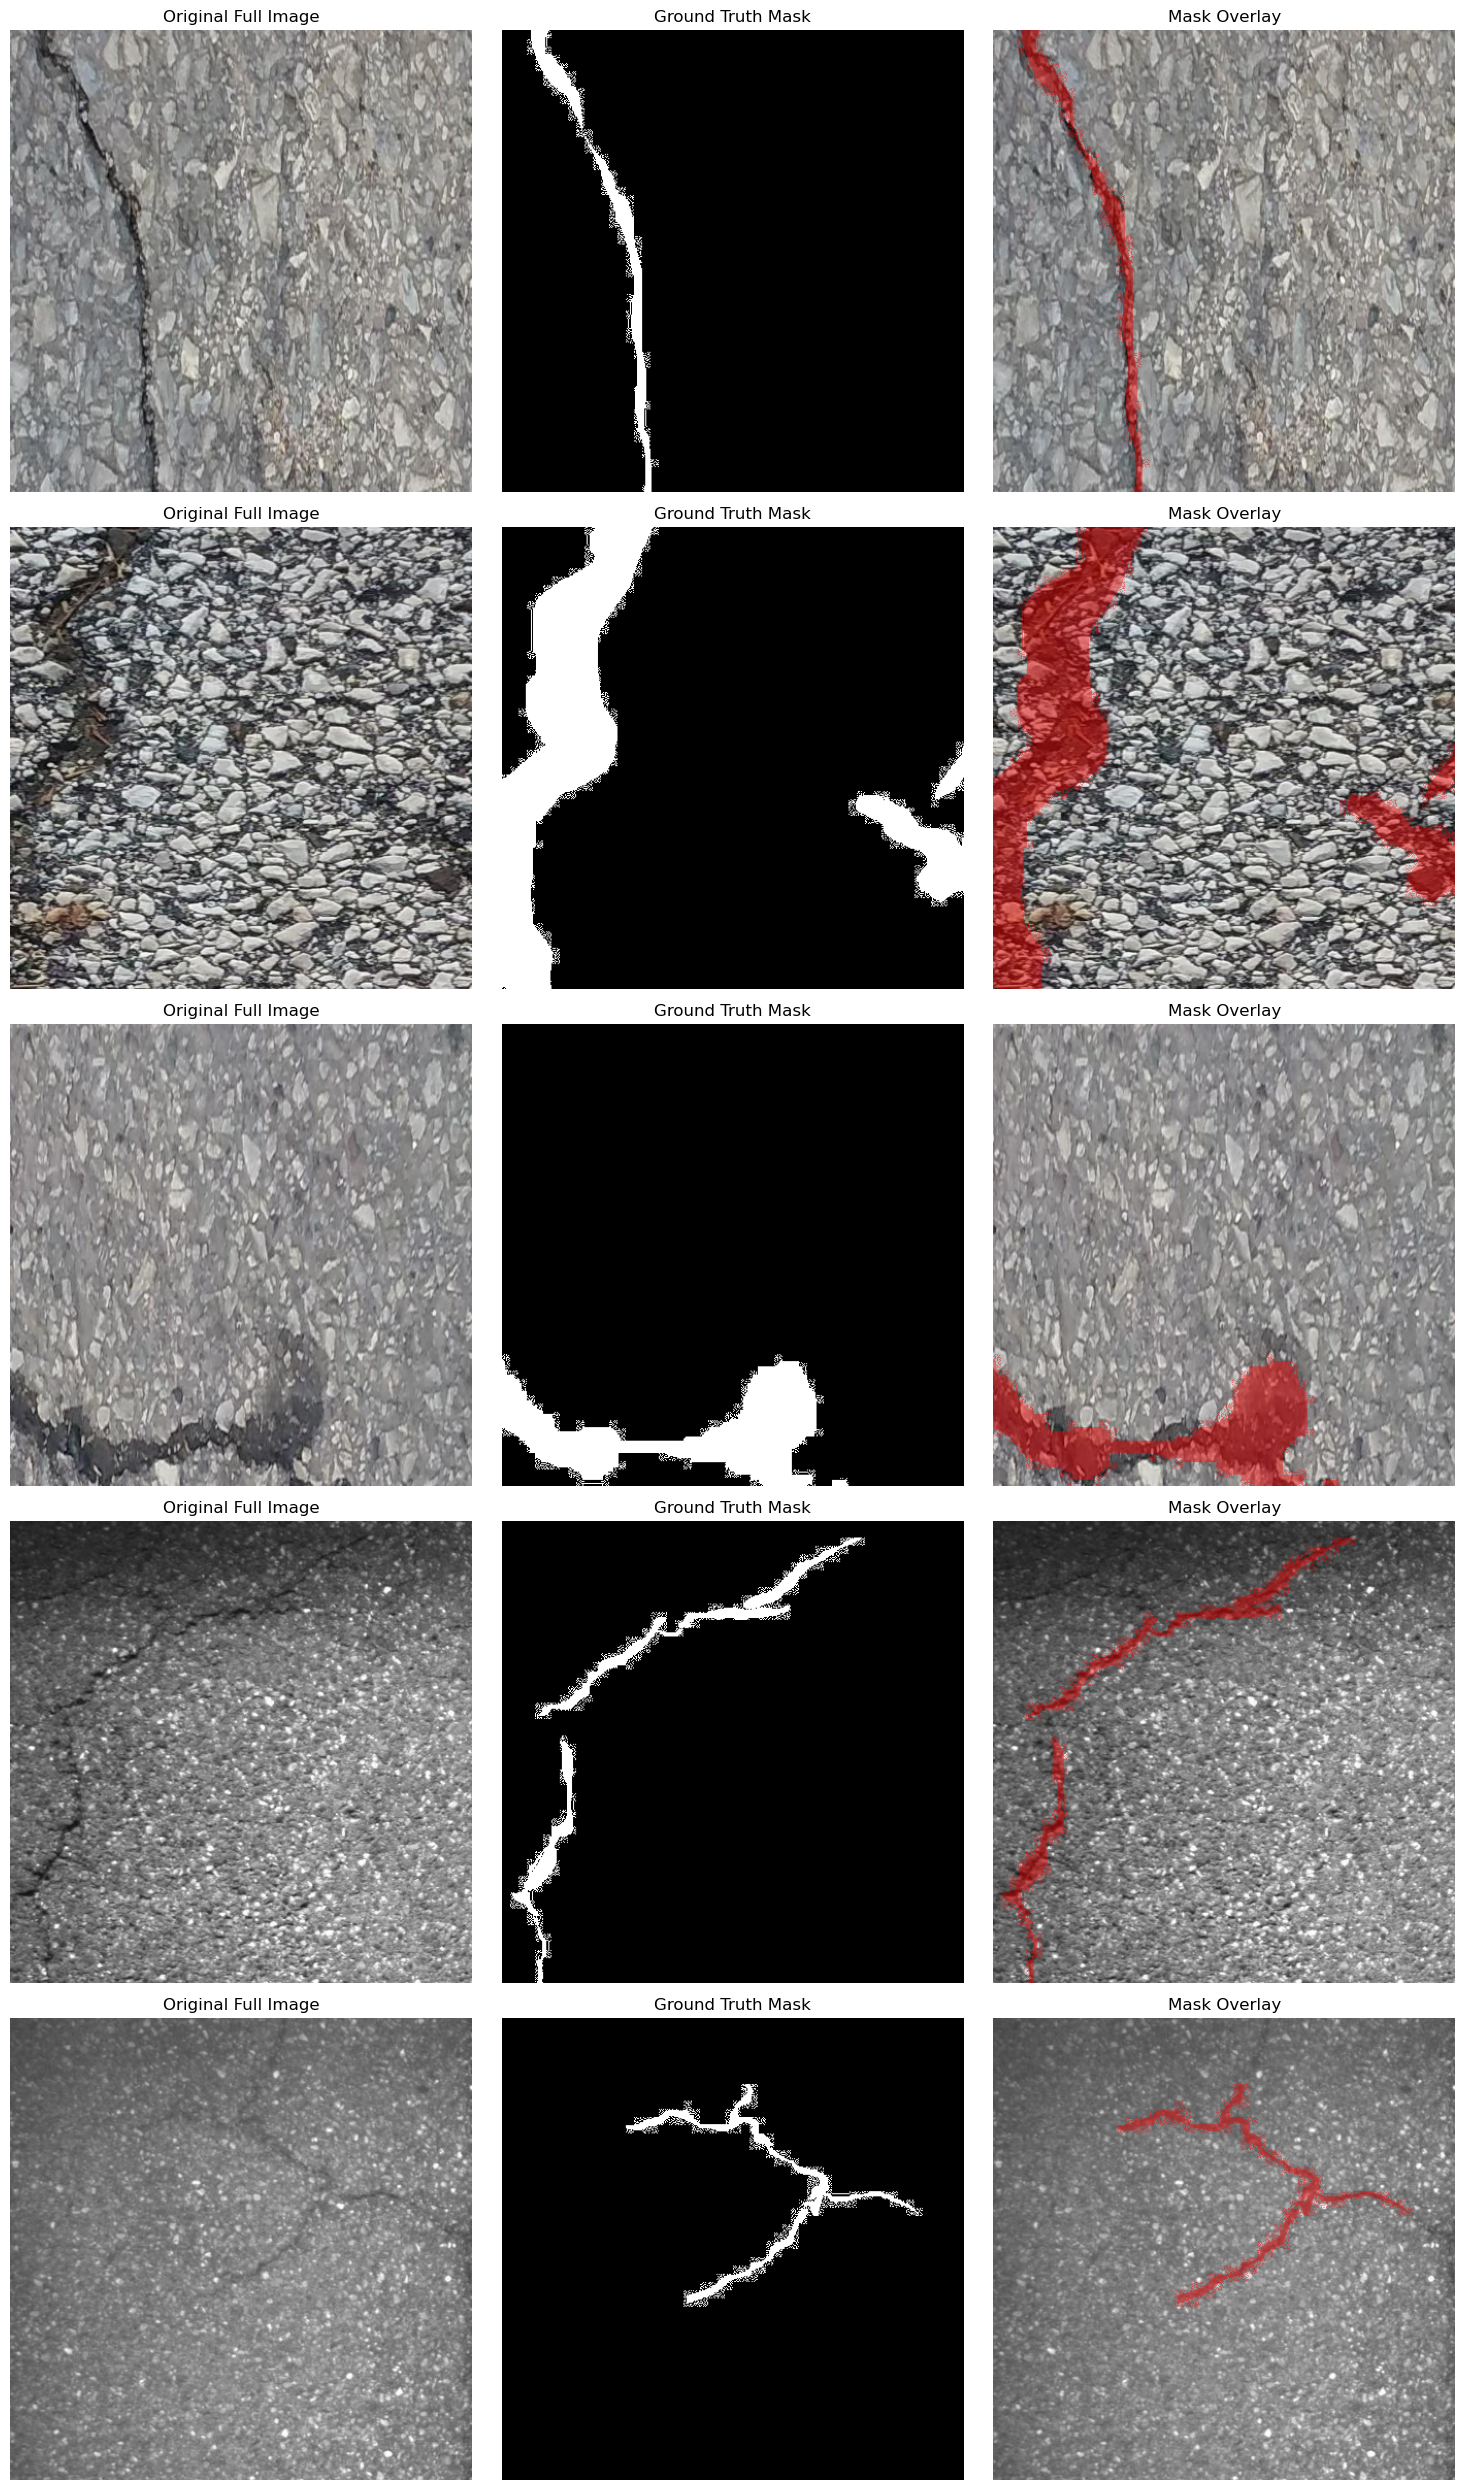

In [5]:
# ============================================================
# STEP 3B: Visualize Full Images, Masks, and Overlays
# ============================================================
# Goal:
# 1. Randomly select full crack image-mask pairs.
# 2. Show original image, ground-truth mask, and overlay.
# 3. Confirm that image-mask matching is correct before patch extraction.
# ============================================================

def visualize_full_image_mask_overlay(pairs, num_images=5):
    """
    Visualize full image-mask pairs.
    """

    selected_pairs = random.sample(pairs, min(num_images, len(pairs)))

    fig, axes = plt.subplots(len(selected_pairs), 3, figsize=(15, 5 * len(selected_pairs)))

    if len(selected_pairs) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (image_path, mask_path) in enumerate(selected_pairs):
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image_np = np.array(image)
        mask_np = np.array(mask)

        mask_bin = (mask_np > 0).astype(np.uint8)

        overlay = image_np.copy()
        red_layer = np.zeros_like(image_np)
        red_layer[:, :, 0] = 255

        alpha = 0.45
        overlay = np.where(
            mask_bin[..., None] == 1,
            ((1 - alpha) * overlay + alpha * red_layer),
            overlay
        ).astype(np.uint8)

        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Original Full Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_bin, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Mask Overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


# Visualize random full image-mask pairs from all valid pairs
visualize_full_image_mask_overlay(
    image_mask_pairs,
    num_images=5
)

In [6]:
# ============================================================
# STEP 4: Extract 96x96 Crack Patches with Quality Filtering
# ============================================================
# Goal:
# 1. Extract 96x96 patches from train/val/test image-level splits.
# 2. Keep image-mask alignment by cropping image and mask together.
# 3. Pad edge patches safely to 96x96.
# 4. Keep useful crack patches.
# 5. Remove poor-quality patches that may hurt topology:
#    - too much padding
#    - too much foreground/crack area
#    - too little meaningful crack content
#
# Why this matters:
# - Too many padded patches can create artificial borders.
# - Very thick foreground patches can teach the model to predict blobs.
# - Balanced patch selection helps both pixel metrics and topology metrics.
# ============================================================


from skimage.morphology import remove_small_objects, remove_small_holes

# ----------------------------
# Patch filtering settings
# ----------------------------
MIN_CRACK_RATIO = 0.01
MAX_CRACK_RATIO = 0.45
EMPTY_KEEP_RATIO = 0.02
MAX_PADDING_RATIO = 0.25

# Mild mask-cleaning settings
MIN_OBJECT_SIZE = 20
MIN_HOLE_SIZE = 20


def clean_crack_mask(mask_patch):
    """
    Mildly clean binary crack mask:
    1. Remove tiny isolated components.
    2. Remove tiny holes/noisy gaps.
    
    This helps topology metrics without destroying real cracks.
    """

    mask_bool = mask_patch.astype(bool)

    mask_bool = remove_small_objects(
        mask_bool,
        min_size=MIN_OBJECT_SIZE
    )

    mask_bool = remove_small_holes(
        mask_bool,
        area_threshold=MIN_HOLE_SIZE
    )

    return mask_bool.astype(np.uint8)


def pad_patch(image_patch, mask_patch, patch_size=PATCH_SIZE):
    """
    Pad image and mask patches to exactly patch_size x patch_size.
    """

    h, w = mask_patch.shape

    pad_h = patch_size - h
    pad_w = patch_size - w

    original_area = h * w
    final_area = patch_size * patch_size
    padding_ratio = 1.0 - (original_area / final_area)

    if pad_h > 0 or pad_w > 0:
        image_patch = np.pad(
            image_patch,
            ((0, pad_h), (0, pad_w), (0, 0)),
            mode="constant",
            constant_values=0
        )

        mask_patch = np.pad(
            mask_patch,
            ((0, pad_h), (0, pad_w)),
            mode="constant",
            constant_values=0
        )

    return image_patch, mask_patch, padding_ratio


def extract_patches_from_pair(
    image_path,
    mask_path,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    min_crack_ratio=MIN_CRACK_RATIO,
    max_crack_ratio=MAX_CRACK_RATIO,
    empty_keep_ratio=EMPTY_KEEP_RATIO,
    max_padding_ratio=MAX_PADDING_RATIO
):
    """
    Extract topology-friendly crack patches from one image-mask pair.
    """

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    image_np = np.array(image)
    mask_np = np.array(mask)

    H, W, _ = image_np.shape

    patches = []

    for top in range(0, H, patch_stride):
        for left in range(0, W, patch_stride):

            bottom = min(top + patch_size, H)
            right = min(left + patch_size, W)

            image_patch = image_np[top:bottom, left:right]
            mask_patch = mask_np[top:bottom, left:right]

            image_patch, mask_patch, padding_ratio = pad_patch(
                image_patch,
                mask_patch,
                patch_size=patch_size
            )

            # Reject heavily padded patches
            if padding_ratio > max_padding_ratio:
                continue

            # Convert to binary mask
            mask_patch = (mask_patch > 0).astype(np.uint8)

            # Mild topology-friendly cleaning
            mask_patch = clean_crack_mask(mask_patch)

            crack_ratio = mask_patch.mean()

            # Reject very thick/blob-like mask patches
            if crack_ratio > max_crack_ratio:
                continue

            # Keep useful crack patches
            if crack_ratio >= min_crack_ratio:
                patches.append((image_patch, mask_patch))

            # Keep small number of empty/background patches
            elif random.random() < empty_keep_ratio:
                patches.append((image_patch, mask_patch))

    return patches


def extract_patches_from_pairs(pairs, split_name):
    """
    Extract patches from all image-mask pairs in one split.
    """

    all_patches = []

    for image_path, mask_path in tqdm(pairs, desc=f"Extracting {split_name} patches"):
        patches = extract_patches_from_pair(
            image_path=image_path,
            mask_path=mask_path
        )

        all_patches.extend(patches)

    return all_patches


# ----------------------------
# Extract patches from image-level splits
# ----------------------------
train_patches = extract_patches_from_pairs(train_pairs, "train")
val_patches = extract_patches_from_pairs(val_pairs, "validation")
test_patches = extract_patches_from_pairs(test_pairs, "test")


# ----------------------------
# Patch statistics
# ----------------------------
def patch_statistics(patches, split_name):
    crack_ratios = [mask.mean() for _, mask in patches]

    print(f"\n{split_name} patch statistics")
    print("-" * 40)
    print("Total patches      :", len(patches))
    print("Mean crack ratio   :", np.mean(crack_ratios))
    print("Min crack ratio    :", np.min(crack_ratios))
    print("Max crack ratio    :", np.max(crack_ratios))
    print("Empty patches      :", sum(r == 0 for r in crack_ratios))
    print("Crack patches      :", sum(r > 0 for r in crack_ratios))


patch_statistics(train_patches, "Train")
patch_statistics(val_patches, "Validation")
patch_statistics(test_patches, "Test")


# ----------------------------
# Verify one patch
# ----------------------------
sample_image, sample_mask = train_patches[0]

print("\nSample patch check")
print("------------------")
print("Image patch shape:", sample_image.shape)
print("Mask patch shape :", sample_mask.shape)
print("Mask values      :", np.unique(sample_mask))







Extracting test patches: 100%|██████████| 1088/1088 [00:13<00:00, 80.50it/s]



Train patch statistics
----------------------------------------
Total patches      : 26356
Mean crack ratio   : 0.11672881155303032
Min crack ratio    : 0.0
Max crack ratio    : 0.4499782986111111
Empty patches      : 1040
Crack patches      : 25316

Validation patch statistics
----------------------------------------
Total patches      : 5718
Mean crack ratio   : 0.11570115601074579
Min crack ratio    : 0.0
Max crack ratio    : 0.4499782986111111
Empty patches      : 223
Crack patches      : 5495

Test patch statistics
----------------------------------------
Total patches      : 5620
Mean crack ratio   : 0.12137268235344999
Min crack ratio    : 0.0
Max crack ratio    : 0.4497612847222222
Empty patches      : 211
Crack patches      : 5409

Sample patch check
------------------
Image patch shape: (96, 96, 3)
Mask patch shape : (96, 96)
Mask values      : [0 1]


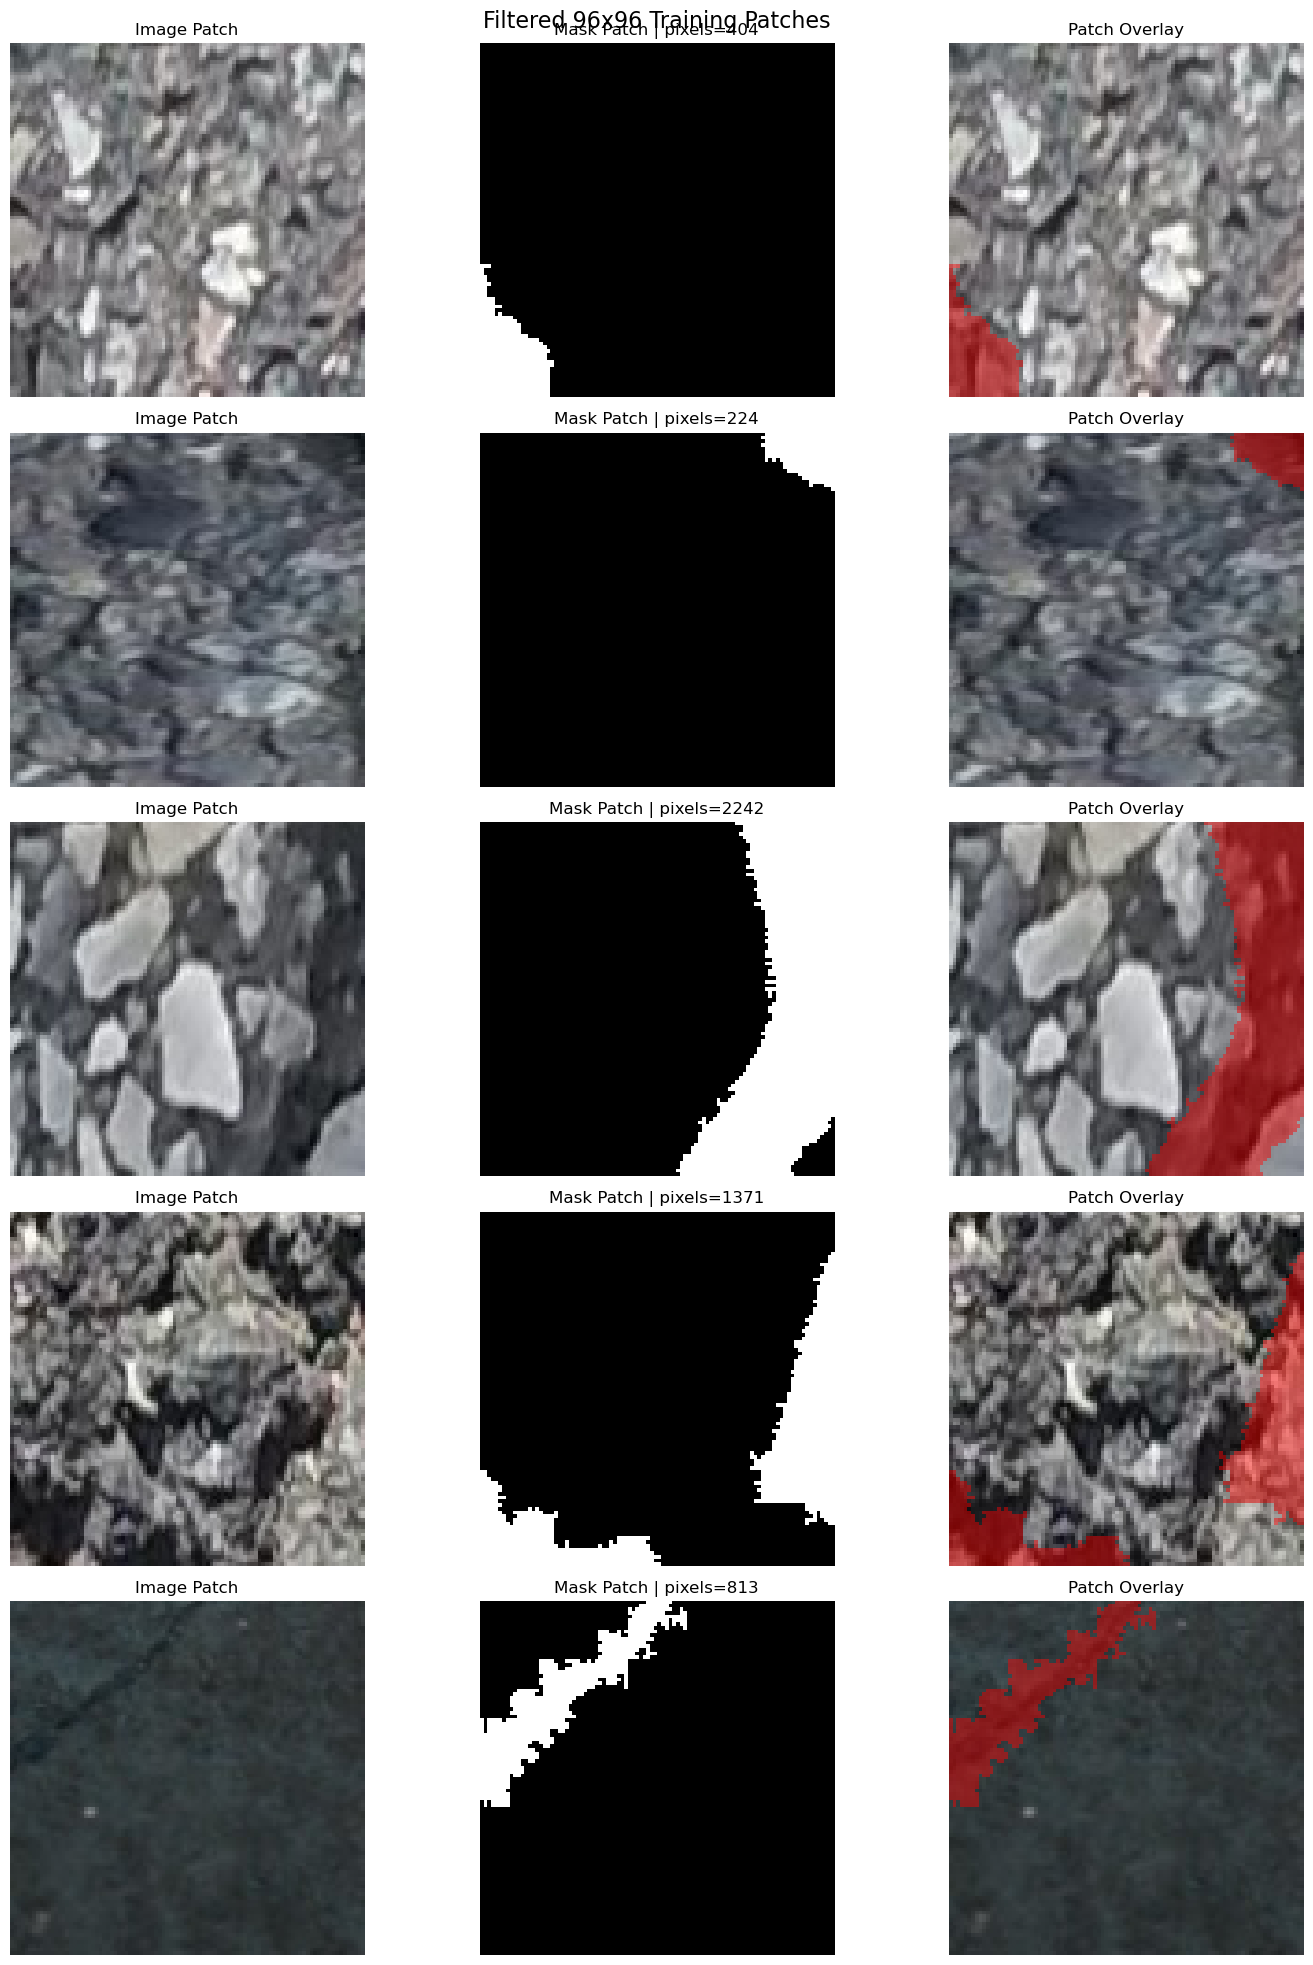

In [7]:
# ============================================================
# STEP 4B: Visualize Filtered 96x96 Patches, Masks, and Overlays
# ============================================================
# Goal:
# 1. Randomly visualize filtered training patches.
# 2. Check that masks are aligned with cracks.
# 3. Confirm that bad thick/padded patches were reduced.
# ============================================================

def visualize_patch_mask_overlay(patches, num_patches=5, title="Filtered 96x96 Training Patches"):
    """
    Visualize random extracted image-mask patches.

    Each item in patches is:
        image_patch: [96, 96, 3]
        mask_patch : [96, 96]
    """

    selected_patches = random.sample(patches, min(num_patches, len(patches)))

    fig, axes = plt.subplots(len(selected_patches), 3, figsize=(15, 4 * len(selected_patches)))

    if len(selected_patches) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (image_patch, mask_patch) in enumerate(selected_patches):
        image_np = image_patch.copy()
        mask_np = mask_patch.copy()

        # Create red overlay
        overlay = image_np.copy()
        red_layer = np.zeros_like(image_np)
        red_layer[:, :, 0] = 255

        alpha = 0.45
        overlay = np.where(
            mask_np[..., None] == 1,
            ((1 - alpha) * overlay + alpha * red_layer),
            overlay
        ).astype(np.uint8)

        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Image Patch")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title(f"Mask Patch | pixels={mask_np.sum()}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Patch Overlay")
        axes[i, 2].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_patch_mask_overlay(
    train_patches,
    num_patches=5,
    title="Filtered 96x96 Training Patches"
)

In [8]:
# ============================================================
# STEP 5: Create PyTorch Dataset and DataLoaders
# ============================================================
# Goal:
# 1. Convert extracted patches into PyTorch tensors.
# 2. Normalize image values from [0,255] → [0,1].
# 3. Convert image shape:
#       [H,W,3] → [3,H,W]
# 4. Convert mask shape:
#       [H,W] → [1,H,W]
# 5. Create train/validation/test DataLoaders.
# 6. Verify tensor shapes carefully.
#
# Important:
# - All patches are already 96x96 from Step 4.
# - Masks are binary: {0,1}
# ============================================================


class CrackPatchDataset(Dataset):
    """
    PyTorch dataset for crack segmentation patches.
    """

    def __init__(self, patches):
        """
        patches:
            list of (image_patch, mask_patch)
        """

        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):

        image_patch, mask_patch = self.patches[idx]

        # ----------------------------
        # Normalize image to [0,1]
        # ----------------------------
        image_patch = image_patch.astype(np.float32) / 255.0

        # ----------------------------
        # Ensure mask is float32
        # ----------------------------
        mask_patch = mask_patch.astype(np.float32)

        # ----------------------------
        # Convert image:
        # [H,W,3] -> [3,H,W]
        # ----------------------------
        image_tensor = torch.from_numpy(image_patch).permute(2, 0, 1)

        # ----------------------------
        # Convert mask:
        # [H,W] -> [1,H,W]
        # ----------------------------
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0)

        return image_tensor, mask_tensor


# ----------------------------
# Create dataset objects
# ----------------------------
train_dataset = CrackPatchDataset(train_patches)
val_dataset = CrackPatchDataset(val_patches)
test_dataset = CrackPatchDataset(test_patches)


# ----------------------------
# DataLoader settings
# ----------------------------
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ----------------------------
# Verify one batch
# ----------------------------
images, masks = next(iter(train_loader))

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print("Train dataset size :", len(train_dataset))
print("Validation size    :", len(val_dataset))
print("Test size          :", len(test_dataset))

print("\nTrain batches      :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))

print("\n" + "=" * 50)
print("BATCH SHAPE CHECK")
print("=" * 50)

print("Image batch shape :", images.shape)
print("Mask batch shape  :", masks.shape)

print("\nExpected image shape : [B, 3, 96, 96]")
print("Expected mask shape  : [B, 1, 96, 96]")

print("\n" + "=" * 50)
print("VALUE CHECK")
print("=" * 50)

print("Image min value :", images.min().item())
print("Image max value :", images.max().item())

print("Mask unique values:", torch.unique(masks))

DATASET SUMMARY
Train dataset size : 26356
Validation size    : 5718
Test size          : 5620

Train batches      : 3295
Validation batches : 715
Test batches       : 703

BATCH SHAPE CHECK
Image batch shape : torch.Size([8, 3, 96, 96])
Mask batch shape  : torch.Size([8, 1, 96, 96])

Expected image shape : [B, 3, 96, 96]
Expected mask shape  : [B, 1, 96, 96]

VALUE CHECK
Image min value : 0.0
Image max value : 1.0
Mask unique values: tensor([0., 1.])


In [9]:
# ============================================================
# STEP 6: Define U-Net Model and Test One Forward Pass
# ============================================================
# Goal:
# 1. Define a U-Net model for binary crack segmentation.
# 2. Input shape : [B, 3, 96, 96]
# 3. Output shape: [B, 1, 96, 96]
#
# Important:
# - The model outputs raw logits.
# - Do NOT apply sigmoid inside the model.
# - Sigmoid will be applied later during loss/metric computation.
# ============================================================


class DoubleConv(nn.Module):
    """
    Two convolution blocks:
        Conv2d -> BatchNorm2d -> ReLU
        Conv2d -> BatchNorm2d -> ReLU
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    """
    U-Net model for binary crack segmentation.

    Encoder:
        Extracts crack-related features.

    Decoder:
        Reconstructs the crack mask.

    Skip connections:
        Preserve fine crack details.
    """

    def __init__(self, in_channels=3, out_channels=1, base_channels=64):
        super().__init__()

        # ----------------------------
        # Encoder
        # ----------------------------
        self.down1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.down2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.down3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.down4 = DoubleConv(base_channels * 4, base_channels * 8)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        # ----------------------------
        # Bottleneck
        # ----------------------------
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)

        # ----------------------------
        # Decoder
        # ----------------------------
        self.up4 = nn.ConvTranspose2d(
            base_channels * 16,
            base_channels * 8,
            kernel_size=2,
            stride=2
        )
        self.conv4 = DoubleConv(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(
            base_channels * 8,
            base_channels * 4,
            kernel_size=2,
            stride=2
        )
        self.conv3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=2,
            stride=2
        )
        self.conv2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=2,
            stride=2
        )
        self.conv1 = DoubleConv(base_channels * 2, base_channels)

        # ----------------------------
        # Final 1x1 convolution
        # ----------------------------
        self.final_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        # ----------------------------
        # Encoder
        # ----------------------------
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        # ----------------------------
        # Bottleneck
        # ----------------------------
        bn = self.bottleneck(p4)

        # ----------------------------
        # Decoder with skip connections
        # ----------------------------
        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        # Raw logits: [B, 1, 96, 96]
        logits = self.final_conv(c8)

        return logits


# ============================================================
# Test One Forward Pass
# ============================================================

# Create test model
test_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

# Get one batch
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Forward pass
test_model.eval()

with torch.no_grad():
    logits = test_model(images)

# ----------------------------
# Shape checks
# ----------------------------
print("=" * 50)
print("U-NET FORWARD PASS CHECK")
print("=" * 50)

print("Input image shape :", images.shape)
print("Output logits shape:", logits.shape)
print("Expected mask shape:", masks.shape)

assert logits.shape == masks.shape, "ERROR: Model output shape does not match mask shape."

# ----------------------------
# Parameter count
# ----------------------------
num_params = sum(
    p.numel() for p in test_model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", num_params)

# Remove test model from GPU memory
del test_model
torch.cuda.empty_cache()

print("\nStep 6 completed successfully.")

U-NET FORWARD PASS CHECK
Input image shape : torch.Size([8, 3, 96, 96])
Output logits shape: torch.Size([8, 1, 96, 96])
Expected mask shape: torch.Size([8, 1, 96, 96])

Trainable parameters: 31037633

Step 6 completed successfully.


In [10]:
# ============================================================
# STEP 7: Define Losses, Learnable Threshold, and Evaluation Metrics
# ============================================================
# Goal:
# 1. Define losses for crack segmentation.
# 2. Define learnable threshold.
# 3. Define pixel-wise and topology-aware metrics.
# 4. Support all final models:
#       BCE only
#       BCE + SATLoss
#       BCE + Dice + clDice
#       BCE + Dice + clDice + SATLoss
#
# Important:
# - Model outputs raw logits.
# - BCEWithLogitsLoss uses raw logits.
# - Dice, clDice, SATLoss use probabilities after sigmoid.
# - Learnable threshold is trained using threshold_dice_loss.
# ============================================================


# ----------------------------
# 7.1 BCE Loss
# ----------------------------
bce_loss_fn = nn.BCEWithLogitsLoss()


# ----------------------------
# 7.2 Dice Loss
# ----------------------------
def dice_loss(probs, targets, eps=1e-8):
    """
    Dice loss for binary crack segmentation.

    probs:
        predicted probabilities after sigmoid, shape [B,1,H,W]

    targets:
        binary ground-truth masks, shape [B,1,H,W]
    """

    probs = probs.float()
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


# ----------------------------
# 7.3 Soft Skeletonization for soft-clDice
# ----------------------------
CLDICE_ITERATIONS = 3


def soft_erode(img):
    """
    Differentiable erosion approximation.
    """

    p1 = -F.max_pool2d(
        -img,
        kernel_size=(3, 1),
        stride=1,
        padding=(1, 0)
    )

    p2 = -F.max_pool2d(
        -img,
        kernel_size=(1, 3),
        stride=1,
        padding=(0, 1)
    )

    return torch.min(p1, p2)


def soft_dilate(img):
    """
    Differentiable dilation approximation.
    """

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):
    """
    Differentiable opening = erosion followed by dilation.
    """

    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=CLDICE_ITERATIONS):
    """
    Differentiable skeletonization approximation.
    Helps preserve crack connectivity.
    """

    img = img.float()

    opened = soft_open(img)
    skeleton = F.relu(img - opened)

    for _ in range(iterations):
        img = soft_erode(img)
        opened = soft_open(img)

        delta = F.relu(img - opened)
        skeleton = skeleton + F.relu(delta - skeleton * delta)

    return skeleton


# ----------------------------
# 7.4 soft-clDice Loss
# ----------------------------
def soft_cldice_loss(probs, targets, iterations=CLDICE_ITERATIONS, eps=1e-8):
    """
    soft-clDice loss for thin crack connectivity.
    """

    probs = probs.float()
    targets = targets.float()

    skel_pred = soft_skeletonize(probs, iterations=iterations)
    skel_true = soft_skeletonize(targets, iterations=iterations)

    tprec = (skel_pred * targets).sum(dim=(1, 2, 3)) / (
        skel_pred.sum(dim=(1, 2, 3)) + eps
    )

    tsens = (skel_true * probs).sum(dim=(1, 2, 3)) / (
        skel_true.sum(dim=(1, 2, 3)) + eps
    )

    cldice = (2.0 * tprec * tsens + eps) / (tprec + tsens + eps)

    return 1.0 - cldice.mean()


# ----------------------------
# 7.5 Foreground Penalty
# ----------------------------
def foreground_penalty(probs, targets):
    """
    Penalizes predicted crack area if it is much larger/smaller than ground truth.

    This helps reduce overly thick crack predictions.
    """

    pred_area = probs.mean(dim=(1, 2, 3))
    true_area = targets.mean(dim=(1, 2, 3))

    return torch.abs(pred_area - true_area).mean()


# ----------------------------
# 7.6 Learnable Threshold
# ----------------------------
class LearnableThreshold(nn.Module):
    """
    Learnable global threshold.

    Instead of fixed threshold = 0.5, this learns a threshold in (0,1).
    """

    def __init__(self, init_value=0.5):
        super().__init__()

        init_value = torch.tensor(init_value, dtype=torch.float32)

        init_logit = torch.log(init_value / (1.0 - init_value))

        self.threshold_logit = nn.Parameter(init_logit)

    def forward(self):
        return torch.sigmoid(self.threshold_logit)


THRESHOLD_SHARPNESS = 20.0
LAMBDA_THRESHOLD = 0.1


def soft_threshold_prediction(probs, threshold_module, sharpness=THRESHOLD_SHARPNESS):
    """
    Differentiable approximation of hard thresholding.

    Hard threshold:
        preds = probs > threshold

    Soft threshold:
        soft_preds = sigmoid(k * (probs - threshold))
    """

    threshold = threshold_module()

    soft_preds = torch.sigmoid(sharpness * (probs - threshold))

    return soft_preds


def threshold_dice_loss(probs, targets, threshold_module, sharpness=THRESHOLD_SHARPNESS, eps=1e-8):
    """
    Dice loss after soft thresholding.
    This allows the threshold value to learn during training.
    """

    soft_preds = soft_threshold_prediction(
        probs,
        threshold_module,
        sharpness=sharpness
    )

    intersection = (soft_preds * targets).sum(dim=(1, 2, 3))
    union = soft_preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


# ----------------------------
# 7.7 Dice Score Metric
# ----------------------------
def dice_score(preds, targets, eps=1e-8):
    """
    Dice score for binary predictions.
    """

    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + eps) / (union + eps)

    return dice.item()


# ----------------------------
# 7.8 Pixel Accuracy
# ----------------------------
def accuracy_score(preds, targets):
    """
    Pixel-wise accuracy.
    """

    preds = preds.float()
    targets = targets.float()

    correct = (preds == targets).float().sum()
    total = targets.numel()

    return (correct / total).item()


# ----------------------------
# 7.9 clDice Metric
# ----------------------------
def cldice_score(pred_np, target_np, eps=1e-8):
    """
    Non-differentiable clDice metric for evaluation.
    """

    pred_np = pred_np.astype(bool)
    target_np = target_np.astype(bool)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    if skel_pred.sum() == 0 and skel_target.sum() == 0:
        return 1.0

    if skel_pred.sum() == 0 or skel_target.sum() == 0:
        return 0.0

    tprec = (skel_pred & target_np).sum() / (skel_pred.sum() + eps)
    tsens = (skel_target & pred_np).sum() / (skel_target.sum() + eps)

    return float((2.0 * tprec * tsens) / (tprec + tsens + eps))


# ----------------------------
# 7.10 Clean Binary Mask for Topology Metrics
# ----------------------------
def clean_binary_for_topology(mask_np, min_size=10, hole_size=10):
    """
    Clean binary mask before beta0/beta1 evaluation.
    """

    mask_bool = mask_np.astype(bool)

    mask_bool = remove_small_objects(
        mask_bool,
        min_size=min_size
    )

    mask_bool = remove_small_holes(
        mask_bool,
        area_threshold=hole_size
    )

    return mask_bool.astype(np.uint8)


# ----------------------------
# 7.11 Betti Numbers
# ----------------------------
def betti_numbers(binary_np):
    """
    beta0 = number of connected components.
    beta1 = number of holes.
    """

    binary_np = binary_np.astype(bool)

    labeled_fg = label(binary_np, connectivity=2)
    beta0 = labeled_fg.max()

    filled = binary_fill_holes(binary_np)
    holes = filled & (~binary_np)

    labeled_holes = label(holes, connectivity=2)
    beta1 = labeled_holes.max()

    return beta0, beta1


def betti_error(pred_np, target_np, clean=True):
    """
    Absolute beta0 and beta1 errors.
    """

    if clean:
        pred_np = clean_binary_for_topology(pred_np)
        target_np = clean_binary_for_topology(target_np)

    b0_pred, b1_pred = betti_numbers(pred_np)
    b0_true, b1_true = betti_numbers(target_np)

    return abs(b0_pred - b0_true), abs(b1_pred - b1_true)


# ----------------------------
# 7.12 Evaluation Function
# ----------------------------
def evaluate_model(model, threshold_module, loader, device, threshold_override=None):
    """
    Evaluate model using thresholded predictions.

    If threshold_override is None:
        use learned threshold.

    If threshold_override is given:
        use fixed threshold value.
    """

    model.eval()
    threshold_module.eval()

    loss_values = []
    acc_values = []
    dice_values = []
    cldice_values = []
    beta0_values = []
    beta1_values = []

    with torch.no_grad():

        if threshold_override is None:
            threshold = threshold_module()
        else:
            threshold = torch.tensor(
                threshold_override,
                device=device,
                dtype=torch.float32
            )

        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)

            preds = (probs > threshold).float()

            loss_values.append(bce.item())
            acc_values.append(accuracy_score(preds.cpu(), masks.cpu()))
            dice_values.append(dice_score(preds.cpu(), masks.cpu()))

            for i in range(images.shape[0]):
                pred_np = preds[i, 0].cpu().numpy().astype(np.uint8)
                mask_np = masks[i, 0].cpu().numpy().astype(np.uint8)

                cldice_values.append(
                    cldice_score(pred_np, mask_np)
                )

                b0_err, b1_err = betti_error(
                    pred_np,
                    mask_np,
                    clean=True
                )

                beta0_values.append(b0_err)
                beta1_values.append(b1_err)

    return {
        "loss": float(np.mean(loss_values)),
        "accuracy": float(np.mean(acc_values)),
        "dice": float(np.mean(dice_values)),
        "cldice": float(np.mean(cldice_values)),
        "beta0_error": float(np.mean(beta0_values)),
        "beta1_error": float(np.mean(beta1_values)),
        "threshold": float(threshold.item())
    }


# ============================================================
# Quick Test on One Batch
# ============================================================

test_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

test_threshold = LearnableThreshold(init_value=0.5).to(device)

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

test_model.eval()

with torch.no_grad():
    logits = test_model(images)
    probs = torch.sigmoid(logits)

test_bce = bce_loss_fn(logits, masks)
test_dice = dice_loss(probs, masks)
test_cldice = soft_cldice_loss(probs, masks)
test_fg = foreground_penalty(probs, masks)
test_thresh = threshold_dice_loss(probs, masks, test_threshold)

print("=" * 50)
print("LOSS TEST ON ONE BATCH")
print("=" * 50)
print("BCE Loss              :", test_bce.item())
print("Dice Loss             :", test_dice.item())
print("soft-clDice Loss      :", test_cldice.item())
print("Foreground Penalty    :", test_fg.item())
print("Threshold Dice Loss   :", test_thresh.item())
print("Initial Threshold     :", test_threshold().item())

del test_model
del test_threshold
torch.cuda.empty_cache()

print("\nStep 7 completed successfully.")

LOSS TEST ON ONE BATCH
BCE Loss              : 0.71599942445755
Dice Loss             : 0.8304623365402222
soft-clDice Loss      : 0.8130764961242676
Foreground Penalty    : 0.4030187129974365
Threshold Dice Loss   : 0.8259835839271545
Initial Threshold     : 0.5

Step 7 completed successfully.


In [11]:
# ============================================================
# STEP 8: SATLoss Creators Only
# ============================================================
# Goal:
# 1. Define topology-aware SATLoss using persistent homology.
# 2. Use only creator points, i.e. birth points of persistence features.
# 3. Compare predicted topology with ground-truth topology.
# 4. Penalize wrong/mismatched creator pixels.
#
# This loss will be used in:
# 1. BCE + SATLoss, creators only
# 2. BCE + Dice + clDice + SATLoss, creators only
#
# Important:
# - GUDHI works with numpy arrays.
# - We detach tensors only for finding persistence pairs.
# - Gradients flow through selected creator pixels in the probability map.
# - Model logits must be converted to probabilities before SATLoss.
# ============================================================


# ----------------------------
# SATLoss settings
# ----------------------------
SAT_MAX_FEATURES = 100
SAT_BATCH_LIMIT = 4


def flat_index_to_yx(index, height, width):
    """
    Convert a flat index from GUDHI into image coordinates (y, x).
    """

    index = int(index)

    # Safety clamp
    index = max(0, min(index, height * width - 1))

    y = index // width
    x = index % width

    return int(y), int(x)


def extract_persistence_features(prob_np, max_features=SAT_MAX_FEATURES, dims=(0, 1)):
    """
    Extract persistence features from a 2D probability map or binary mask.

    Input:
        prob_np: 2D numpy array with values in [0,1]

    Output:
        features: list of dictionaries containing:
            dim       : topological dimension, 0 or 1
            birth_xy  : creator pixel position
            death_xy  : destroyer pixel position
            birth_val : value at creator pixel
            death_val : value at destroyer pixel
            persistence: |birth_val - death_val|
    """

    prob_np = np.asarray(prob_np, dtype=np.float64)

    H, W = prob_np.shape

    # Negative probability means high crack probability appears earlier.
    filtration = -prob_np

    try:
        cubical_complex = gudhi.CubicalComplex(
            top_dimensional_cells=filtration
        )

        cubical_complex.persistence()

        pairs, _ = cubical_complex.cofaces_of_persistence_pairs()

    except Exception:
        return []

    features = []

    for dim in dims:
        if dim >= len(pairs):
            continue

        for pair in pairs[dim]:

            # Skip incomplete or infinite features
            if len(pair) < 2:
                continue

            birth_index = int(pair[0])
            death_index = int(pair[1])

            by, bx = flat_index_to_yx(birth_index, H, W)
            dy, dx = flat_index_to_yx(death_index, H, W)

            birth_val = float(prob_np[by, bx])
            death_val = float(prob_np[dy, dx])

            persistence = abs(birth_val - death_val)

            features.append({
                "dim": dim,
                "birth_xy": (by, bx),
                "death_xy": (dy, dx),
                "birth_val": birth_val,
                "death_val": death_val,
                "persistence": persistence
            })

    # Keep strongest topological features only
    features = sorted(
        features,
        key=lambda f: f["persistence"],
        reverse=True
    )

    return features[:max_features]


def satloss_creators_single(
    prob_tensor,
    mask_tensor,
    max_features=SAT_MAX_FEATURES
):
    """
    Compute SATLoss creators-only for one image.

    Inputs:
        prob_tensor: [H,W] predicted probability map
        mask_tensor: [H,W] binary ground-truth mask

    Creators-only idea:
        - Use birth/creator points from persistence pairs.
        - Match predicted creator points to ground-truth creator points.
        - Push predicted creator probability toward the matched target creator value.
    """

    device = prob_tensor.device
    H, W = prob_tensor.shape

    # GUDHI needs numpy arrays
    prob_np = prob_tensor.detach().cpu().numpy()
    mask_np = mask_tensor.detach().cpu().numpy()

    mask_np = (mask_np > 0).astype(np.float64)

    pred_features = extract_persistence_features(
        prob_np,
        max_features=max_features,
        dims=(0, 1)
    )

    true_features = extract_persistence_features(
        mask_np,
        max_features=max_features,
        dims=(0, 1)
    )

    # If prediction has no features, no topology penalty
    if len(pred_features) == 0:
        return torch.tensor(0.0, device=device, dtype=torch.float32)

    total_loss = torch.tensor(0.0, device=device, dtype=torch.float32)

    for pf in pred_features:
        by, bx = pf["birth_xy"]

        # Creator pixel in prediction, gradient flows here
        pred_birth = prob_tensor[by, bx]

        best_tf = None
        best_cost = None

        # Match to nearest ground-truth feature of the same dimension
        for tf in true_features:
            if tf["dim"] != pf["dim"]:
                continue

            tby, tbx = tf["birth_xy"]

            # Spatial-aware creator matching
            spatial_cost = (
                ((by / H) - (tby / H)) ** 2
                + ((bx / W) - (tbx / W)) ** 2
            )

            value_cost = (
                pf["birth_val"] - tf["birth_val"]
            ) ** 2

            cost = value_cost + 0.1 * spatial_cost

            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_tf = tf

        # ----------------------------
        # Case 1: matched creator
        # ----------------------------
        if best_tf is not None:
            target_birth = torch.tensor(
                best_tf["birth_val"],
                device=device,
                dtype=torch.float32
            )

            total_loss = total_loss + (pred_birth - target_birth) ** 2

        # ----------------------------
        # Case 2: unmatched creator
        # Push weak/noisy predicted creator toward background.
        # ----------------------------
        else:
            total_loss = total_loss + pred_birth ** 2

    return total_loss / len(pred_features)


def satloss_creators_batch(
    probs,
    masks,
    batch_limit=SAT_BATCH_LIMIT,
    max_features=SAT_MAX_FEATURES
):
    """
    Compute creators-only SATLoss for a batch.

    Inputs:
        probs: [B,1,H,W] predicted probabilities
        masks: [B,1,H,W] binary masks

    For speed:
        only first batch_limit images are used.
    """

    B = probs.shape[0]
    use_B = min(B, batch_limit)

    losses = []

    for i in range(use_B):
        prob_i = probs[i, 0]
        mask_i = masks[i, 0]

        loss_i = satloss_creators_single(
            prob_i,
            mask_i,
            max_features=max_features
        )

        losses.append(loss_i)

    if len(losses) == 0:
        return torch.tensor(0.0, device=probs.device, dtype=torch.float32)

    return torch.stack(losses).mean()


# ============================================================
# Quick Test on One Batch
# ============================================================

sat_test_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

sat_test_model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = sat_test_model(images)
    probs = torch.sigmoid(logits)

sat_creator_loss = satloss_creators_batch(
    probs,
    masks,
    batch_limit=SAT_BATCH_LIMIT,
    max_features=SAT_MAX_FEATURES
)

print("=" * 50)
print("SATLOSS CREATORS-ONLY TEST")
print("=" * 50)
print("Probability shape:", probs.shape)
print("Mask shape       :", masks.shape)
print("SATLoss creators :", sat_creator_loss.item())

del sat_test_model
torch.cuda.empty_cache()

print("\nStep 8 completed successfully.")

SATLOSS CREATORS-ONLY TEST
Probability shape: torch.Size([8, 1, 96, 96])
Mask shape       : torch.Size([8, 1, 96, 96])
SATLoss creators : 0.2496538758277893

Step 8 completed successfully.


In [12]:
# ============================================================
# STEP 9: SATLoss Creators + Destroyers
# ============================================================
# Goal:
# 1. Define topology-aware SATLoss using both:
#       - creators  = birth points
#       - destroyers = death points
# 2. Match predicted persistence features with ground-truth features.
# 3. Penalize mismatch at both birth and death pixels.
# 4. Push unmatched predicted features toward the persistence diagonal.
#
# This loss will be used in:
# 1. BCE + SATLoss, creators + destroyers
# 2. BCE + Dice + clDice + SATLoss, creators + destroyers
#
# Important:
# - GUDHI is used only to locate birth/death pixels.
# - Gradients flow through selected probability pixels.
# - The model output must be converted to probabilities before SATLoss.
# ============================================================


def satloss_creator_destroyer_single(
    prob_tensor,
    mask_tensor,
    max_features=SAT_MAX_FEATURES
):
    """
    Compute SATLoss using both creators and destroyers for one image.

    Inputs:
        prob_tensor: [H,W] predicted probability map
        mask_tensor: [H,W] binary ground-truth mask

    Creator-destroyer idea:
        - birth point = creator of a topological feature
        - death point = destroyer of a topological feature
        - matched features penalize both birth and death value mismatch
        - unmatched predicted features are pushed toward the diagonal
    """

    device = prob_tensor.device
    H, W = prob_tensor.shape

    # Convert to numpy only for persistence feature extraction
    prob_np = prob_tensor.detach().cpu().numpy()
    mask_np = mask_tensor.detach().cpu().numpy()

    mask_np = (mask_np > 0).astype(np.float64)

    pred_features = extract_persistence_features(
        prob_np,
        max_features=max_features,
        dims=(0, 1)
    )

    true_features = extract_persistence_features(
        mask_np,
        max_features=max_features,
        dims=(0, 1)
    )

    if len(pred_features) == 0:
        return torch.tensor(0.0, device=device, dtype=torch.float32)

    total_loss = torch.tensor(0.0, device=device, dtype=torch.float32)

    for pf in pred_features:
        by, bx = pf["birth_xy"]
        dy, dx = pf["death_xy"]

        # Prediction creator and destroyer pixels.
        # Gradients flow through these pixels.
        pred_birth = prob_tensor[by, bx]
        pred_death = prob_tensor[dy, dx]

        best_tf = None
        best_cost = None

        # Match predicted feature to closest true feature of same dimension
        for tf in true_features:
            if tf["dim"] != pf["dim"]:
                continue

            tby, tbx = tf["birth_xy"]
            tdy, tdx = tf["death_xy"]

            # Spatial cost for both creator and destroyer locations
            spatial_birth = (
                ((by / H) - (tby / H)) ** 2
                + ((bx / W) - (tbx / W)) ** 2
            )

            spatial_death = (
                ((dy / H) - (tdy / H)) ** 2
                + ((dx / W) - (tdx / W)) ** 2
            )

            spatial_cost = spatial_birth + spatial_death

            # Diagram/value cost
            value_cost = (
                (pf["birth_val"] - tf["birth_val"]) ** 2
                + (pf["death_val"] - tf["death_val"]) ** 2
            )

            cost = value_cost + 0.1 * spatial_cost

            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_tf = tf

        # ----------------------------
        # Case 1: matched feature
        # Penalize both creator and destroyer mismatch.
        # ----------------------------
        if best_tf is not None:
            target_birth = torch.tensor(
                best_tf["birth_val"],
                device=device,
                dtype=torch.float32
            )

            target_death = torch.tensor(
                best_tf["death_val"],
                device=device,
                dtype=torch.float32
            )

            total_loss = total_loss + (
                (pred_birth - target_birth) ** 2
                + (pred_death - target_death) ** 2
            )

        # ----------------------------
        # Case 2: unmatched feature
        # Push feature toward diagonal:
        # birth and death should become similar,
        # reducing persistence of noisy topology.
        # ----------------------------
        else:
            midpoint = 0.5 * (pred_birth + pred_death)

            total_loss = total_loss + (
                (pred_birth - midpoint) ** 2
                + (pred_death - midpoint) ** 2
            )

    return total_loss / len(pred_features)


def satloss_creator_destroyer_batch(
    probs,
    masks,
    batch_limit=SAT_BATCH_LIMIT,
    max_features=SAT_MAX_FEATURES
):
    """
    Compute creators + destroyers SATLoss for a batch.

    Inputs:
        probs: [B,1,H,W] predicted probabilities
        masks: [B,1,H,W] binary ground-truth masks

    For speed:
        only first batch_limit images are used.
    """

    B = probs.shape[0]
    use_B = min(B, batch_limit)

    losses = []

    for i in range(use_B):
        prob_i = probs[i, 0]
        mask_i = masks[i, 0]

        loss_i = satloss_creator_destroyer_single(
            prob_i,
            mask_i,
            max_features=max_features
        )

        losses.append(loss_i)

    if len(losses) == 0:
        return torch.tensor(0.0, device=probs.device, dtype=torch.float32)

    return torch.stack(losses).mean()


# ============================================================
# Quick Test on One Batch
# ============================================================

sat_cd_test_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

sat_cd_test_model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = sat_cd_test_model(images)
    probs = torch.sigmoid(logits)

sat_cd_loss = satloss_creator_destroyer_batch(
    probs,
    masks,
    batch_limit=SAT_BATCH_LIMIT,
    max_features=SAT_MAX_FEATURES
)

print("=" * 50)
print("SATLOSS CREATORS + DESTROYERS TEST")
print("=" * 50)
print("Probability shape:", probs.shape)
print("Mask shape       :", masks.shape)
print("SATLoss C+D      :", sat_cd_loss.item())

del sat_cd_test_model
torch.cuda.empty_cache()

print("\nStep 9 completed successfully.")

SATLOSS CREATORS + DESTROYERS TEST
Probability shape: torch.Size([8, 1, 96, 96])
Mask shape       : torch.Size([8, 1, 96, 96])
SATLoss C+D      : 2.777264000997093e-07

Step 9 completed successfully.


In [14]:
# ============================================================
# STEP 10: Common Training Functions for All Final Models
# ============================================================
# Goal:
# 1. Define one reusable training system.
# 2. Train each model with its own loss configuration.
# 3. Keep models independent and fairly comparable.
#
# Final models:
# 1. BCE only
# 2. BCE + SATLoss creators only
# 3. BCE + SATLoss creators + destroyers
# 4. BCE + Dice + clDice
# 5. BCE + Dice + clDice + SATLoss creators only
# 6. BCE + Dice + clDice + SATLoss creators + destroyers
# ============================================================

# ----------------------------
# Training settings
# ----------------------------
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3

LAMBDA_BCE = 1.0
LAMBDA_DICE = 0.5
LAMBDA_CLDICE = 0.5
LAMBDA_SAT = 1e-2
LAMBDA_FOREGROUND = 0.2
LAMBDA_THRESHOLD = 0.1


# ----------------------------
# Model configurations
# ----------------------------
model_configs = {
    "bce_only": {
        "display_name": "BCE only",
        "use_bce": True,
        "use_dice": False,
        "use_cldice": False,
        "use_sat": False,
        "sat_type": None,
        "use_foreground": False,
        "use_threshold_loss": True
    },

    "bce_sat_creators": {
        "display_name": "BCE + SATLoss creators only",
        "use_bce": True,
        "use_dice": False,
        "use_cldice": False,
        "use_sat": True,
        "sat_type": "creators",
        "use_foreground": True,
        "use_threshold_loss": True
    },

    "bce_sat_creators_destroyers": {
        "display_name": "BCE + SATLoss creators + destroyers",
        "use_bce": True,
        "use_dice": False,
        "use_cldice": False,
        "use_sat": True,
        "sat_type": "creators_destroyers",
        "use_foreground": True,
        "use_threshold_loss": True
    },

    "hybrid_bce_dice_cldice": {
        "display_name": "BCE + Dice + clDice",
        "use_bce": True,
        "use_dice": True,
        "use_cldice": True,
        "use_sat": False,
        "sat_type": None,
        "use_foreground": True,
        "use_threshold_loss": True
    },

    "hybrid_sat_creators": {
        "display_name": "BCE + Dice + clDice + SATLoss creators only",
        "use_bce": True,
        "use_dice": True,
        "use_cldice": True,
        "use_sat": True,
        "sat_type": "creators",
        "use_foreground": True,
        "use_threshold_loss": True
    },

    "hybrid_sat_creators_destroyers": {
        "display_name": "BCE + Dice + clDice + SATLoss creators + destroyers",
        "use_bce": True,
        "use_dice": True,
        "use_cldice": True,
        "use_sat": True,
        "sat_type": "creators_destroyers",
        "use_foreground": True,
        "use_threshold_loss": True
    }
}


# ----------------------------
# Compute total loss
# ----------------------------
def compute_training_loss(logits, masks, threshold_module, config):
    """
    Compute the total training loss based on model configuration.
    """

    probs = torch.sigmoid(logits)

    total_loss = torch.tensor(0.0, device=logits.device)

    loss_parts = {
        "bce": 0.0,
        "dice": 0.0,
        "cldice": 0.0,
        "sat": 0.0,
        "foreground": 0.0,
        "threshold": 0.0
    }

    # BCE loss
    if config["use_bce"]:
        bce = bce_loss_fn(logits, masks)
        total_loss = total_loss + LAMBDA_BCE * bce
        loss_parts["bce"] = bce.item()

    # Dice loss
    if config["use_dice"]:
        dloss = dice_loss(probs, masks)
        total_loss = total_loss + LAMBDA_DICE * dloss
        loss_parts["dice"] = dloss.item()

    # soft-clDice loss
    if config["use_cldice"]:
        closs = soft_cldice_loss(
            probs,
            masks,
            iterations=CLDICE_ITERATIONS
        )
        total_loss = total_loss + LAMBDA_CLDICE * closs
        loss_parts["cldice"] = closs.item()

    # Foreground penalty
    if config["use_foreground"]:
        fg = foreground_penalty(probs, masks)
        total_loss = total_loss + LAMBDA_FOREGROUND * fg
        loss_parts["foreground"] = fg.item()

    # Learnable threshold loss
    if config["use_threshold_loss"]:
        thresh_loss = threshold_dice_loss(
            probs,
            masks,
            threshold_module,
            sharpness=THRESHOLD_SHARPNESS
        )
        total_loss = total_loss + LAMBDA_THRESHOLD * thresh_loss
        loss_parts["threshold"] = thresh_loss.item()

    # SATLoss
    if config["use_sat"]:
        if config["sat_type"] == "creators":
            sat = satloss_creators_batch(
                probs,
                masks,
                batch_limit=SAT_BATCH_LIMIT,
                max_features=SAT_MAX_FEATURES
            )

        elif config["sat_type"] == "creators_destroyers":
            sat = satloss_creator_destroyer_batch(
                probs,
                masks,
                batch_limit=SAT_BATCH_LIMIT,
                max_features=SAT_MAX_FEATURES
            )

        else:
            raise ValueError("Unknown SATLoss type.")

        total_loss = total_loss + LAMBDA_SAT * sat
        loss_parts["sat"] = sat.item()

    loss_parts["total"] = total_loss.item()

    return total_loss, loss_parts


# ----------------------------
# Train one epoch
# ----------------------------
def train_one_epoch(model, threshold_module, loader, optimizer, config, device):
    """
    Train one model for one epoch using its own loss configuration.
    """

    model.train()
    threshold_module.train()

    epoch_losses = {
        "total": 0.0,
        "bce": 0.0,
        "dice": 0.0,
        "cldice": 0.0,
        "sat": 0.0,
        "foreground": 0.0,
        "threshold": 0.0
    }

    for images, masks in tqdm(loader, desc=f"Training {config['display_name']}"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss, loss_parts = compute_training_loss(
            logits,
            masks,
            threshold_module,
            config
        )

        loss.backward()
        optimizer.step()

        for key in epoch_losses:
            epoch_losses[key] += loss_parts[key]

    for key in epoch_losses:
        epoch_losses[key] /= len(loader)

    epoch_losses["learned_threshold"] = threshold_module().item()

    return epoch_losses


# ----------------------------
# Train full model
# ----------------------------
def train_model(config_key, config, train_loader, val_loader, device):
    """
    Train one complete model with its own configuration.
    """

    print("\n" + "=" * 70)
    print("Training model:", config["display_name"])
    print("=" * 70)

    model = UNet(
        in_channels=3,
        out_channels=1,
        base_channels=64
    ).to(device)

    threshold_module = LearnableThreshold(init_value=0.5).to(device)

    optimizer = optim.Adam(
        list(model.parameters()) + list(threshold_module.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=max(1, EPOCHS // 2),
        gamma=0.1
    )

    history = {
        "train_total_loss": [],
        "train_bce_loss": [],
        "train_dice_loss": [],
        "train_cldice_loss": [],
        "train_sat_loss": [],
        "train_foreground_loss": [],
        "train_threshold_loss": [],
        "learned_threshold": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_dice": [],
        "val_cldice": [],
        "val_beta0_error": [],
        "val_beta1_error": [],
        "val_threshold": []
    }

    best_val_dice = -1.0
    best_model_path = f"saved_models/best_{config_key}.pth"
    best_threshold_path = f"saved_models/best_{config_key}_threshold.pth"

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        print("-" * 50)

        train_metrics = train_one_epoch(
            model,
            threshold_module,
            train_loader,
            optimizer,
            config,
            device
        )

        val_metrics = evaluate_model(
            model,
            threshold_module,
            val_loader,
            device
        )

        scheduler.step()

        history["train_total_loss"].append(train_metrics["total"])
        history["train_bce_loss"].append(train_metrics["bce"])
        history["train_dice_loss"].append(train_metrics["dice"])
        history["train_cldice_loss"].append(train_metrics["cldice"])
        history["train_sat_loss"].append(train_metrics["sat"])
        history["train_foreground_loss"].append(train_metrics["foreground"])
        history["train_threshold_loss"].append(train_metrics["threshold"])
        history["learned_threshold"].append(train_metrics["learned_threshold"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_cldice"].append(val_metrics["cldice"])
        history["val_beta0_error"].append(val_metrics["beta0_error"])
        history["val_beta1_error"].append(val_metrics["beta1_error"])
        history["val_threshold"].append(val_metrics["threshold"])

        print(f"Train Total Loss       : {train_metrics['total']:.4f}")
        print(f"Train BCE Loss         : {train_metrics['bce']:.4f}")
        print(f"Train Dice Loss        : {train_metrics['dice']:.4f}")
        print(f"Train soft-clDice Loss : {train_metrics['cldice']:.4f}")
        print(f"Train SATLoss          : {train_metrics['sat']:.4f}")
        print(f"Train Foreground Loss  : {train_metrics['foreground']:.4f}")
        print(f"Train Threshold Loss   : {train_metrics['threshold']:.4f}")
        print(f"Learned Threshold      : {train_metrics['learned_threshold']:.4f}")

        print(f"Val BCE Loss           : {val_metrics['loss']:.4f}")
        print(f"Val Accuracy           : {val_metrics['accuracy']:.4f}")
        print(f"Val Dice               : {val_metrics['dice']:.4f}")
        print(f"Val clDice             : {val_metrics['cldice']:.4f}")
        print(f"Val beta0 err          : {val_metrics['beta0_error']:.4f}")
        print(f"Val beta1 err          : {val_metrics['beta1_error']:.4f}")
        print(f"Val Threshold          : {val_metrics['threshold']:.4f}")

        if val_metrics["dice"] > best_val_dice:
            best_val_dice = val_metrics["dice"]

            torch.save(model.state_dict(), best_model_path)
            torch.save(threshold_module.state_dict(), best_threshold_path)

            print("Best model updated and saved.")

    print("\nTraining finished:", config["display_name"])
    print("Best validation Dice:", best_val_dice)

    return {
        "model": model,
        "threshold": threshold_module,
        "history": history,
        "best_model_path": best_model_path,
        "best_threshold_path": best_threshold_path,
        "best_val_dice": best_val_dice
    }


print("Step 10 completed successfully.")

Step 10 completed successfully.


In [15]:
# ============================================================
# STEP 11: Train Model 1 — BCE Only
# ============================================================
# Model:
#     BCE only
#
# Goal:
# 1. Train the baseline crack segmentation model.
# 2. Use only BCE loss for pixel-wise crack/background learning.
# 3. Save the best model using validation Dice.
# ============================================================

model_1_results = train_model(
    config_key="bce_only",
    config=model_configs["bce_only"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 1 training completed.")
print("Best model path:", model_1_results["best_model_path"])
print("Best threshold path:", model_1_results["best_threshold_path"])
print("Best validation Dice:", model_1_results["best_val_dice"])


Training model: BCE only

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:25<00:00, 27.81it/s]


Train Total Loss       : 0.3102
Train BCE Loss         : 0.2536
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0000
Train Threshold Loss   : 0.5659
Learned Threshold      : 0.3243
Val BCE Loss           : 0.2345
Val Accuracy           : 0.8776
Val Dice               : 0.5832
Val clDice             : 0.5522
Val beta0 err          : 2.5939
Val beta1 err          : 0.3116
Val Threshold          : 0.3243
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:25<00:00, 27.62it/s]


Train Total Loss       : 0.2719
Train BCE Loss         : 0.2227
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0000
Train Threshold Loss   : 0.4926
Learned Threshold      : 0.3384
Val BCE Loss           : 0.2575
Val Accuracy           : 0.8660
Val Dice               : 0.5650
Val clDice             : 0.5093
Val beta0 err          : 3.2228
Val beta1 err          : 0.2552
Val Threshold          : 0.3384

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.2387
Train BCE Loss         : 0.1949
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0000
Train Threshold Loss   : 0.4383
Learned Threshold      : 0.3616
Val BCE Loss           : 0.2003
Val Accuracy           : 0.9146
Val Dice               : 0.6277
Val clDice             : 0.6007
Val beta0 err          : 1.5066
Val beta1 err          : 0.1149
Val Threshold          : 0.3616

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:20<00:00, 35.51it/s]


Train Total Loss       : 0.2383
Train BCE Loss         : 0.1946
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0000
Train Threshold Loss   : 0.4372
Learned Threshold      : 0.3623
Val BCE Loss           : 0.2003
Val Accuracy           : 0.9151
Val Dice               : 0.6269
Val clDice             : 0.5961
Val beta0 err          : 1.5061
Val beta1 err          : 0.1147
Val Threshold          : 0.3623

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:20<00:00, 34.37it/s]

Train Total Loss       : 0.2381
Train BCE Loss         : 0.1944
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0000
Train Threshold Loss   : 0.4364
Learned Threshold      : 0.3625
Val BCE Loss           : 0.2011
Val Accuracy           : 0.9136
Val Dice               : 0.6274
Val clDice             : 0.5977
Val beta0 err          : 1.4092
Val beta1 err          : 0.1090
Val Threshold          : 0.3625

Training finished: BCE only
Best validation Dice: 0.6331941663906291

Model 1 training completed.
Best model path: saved_models/best_bce_only.pth
Best threshold path: saved_models/best_bce_only_threshold.pth
Best validation Dice: 0.6331941663906291


In [16]:
# ============================================================
# STEP 11B: Evaluate Model 1 — BCE Only
# ============================================================
# Goal:
# 1. Load the best BCE-only model.
# 2. Load its learned threshold.
# 3. Evaluate on the test set.
# 4. Report pixel-wise and topology metrics.
# ============================================================

# Create fresh model and threshold
model_1_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_1_best = LearnableThreshold(init_value=0.5).to(device)

# Load saved best weights
model_1_best.load_state_dict(
    torch.load(model_1_results["best_model_path"], map_location=device)
)

threshold_1_best.load_state_dict(
    torch.load(model_1_results["best_threshold_path"], map_location=device)
)

# Evaluate on test set
model_1_test_metrics = evaluate_model(
    model=model_1_best,
    threshold_module=threshold_1_best,
    loader=test_loader,
    device=device
)

print("=" * 60)
print("MODEL 1 TEST RESULTS: BCE ONLY")
print("=" * 60)
print(f"Test BCE Loss  : {model_1_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_1_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_1_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_1_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_1_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_1_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_1_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:20<00:00, 33.93it/s]

MODEL 1 TEST RESULTS: BCE ONLY
Test BCE Loss  : 0.2119
Test Accuracy  : 0.9042
Test Dice      : 0.6308
Test clDice    : 0.6002
Test beta0 err : 1.7445
Test beta1 err : 0.1461
Threshold      : 0.3617


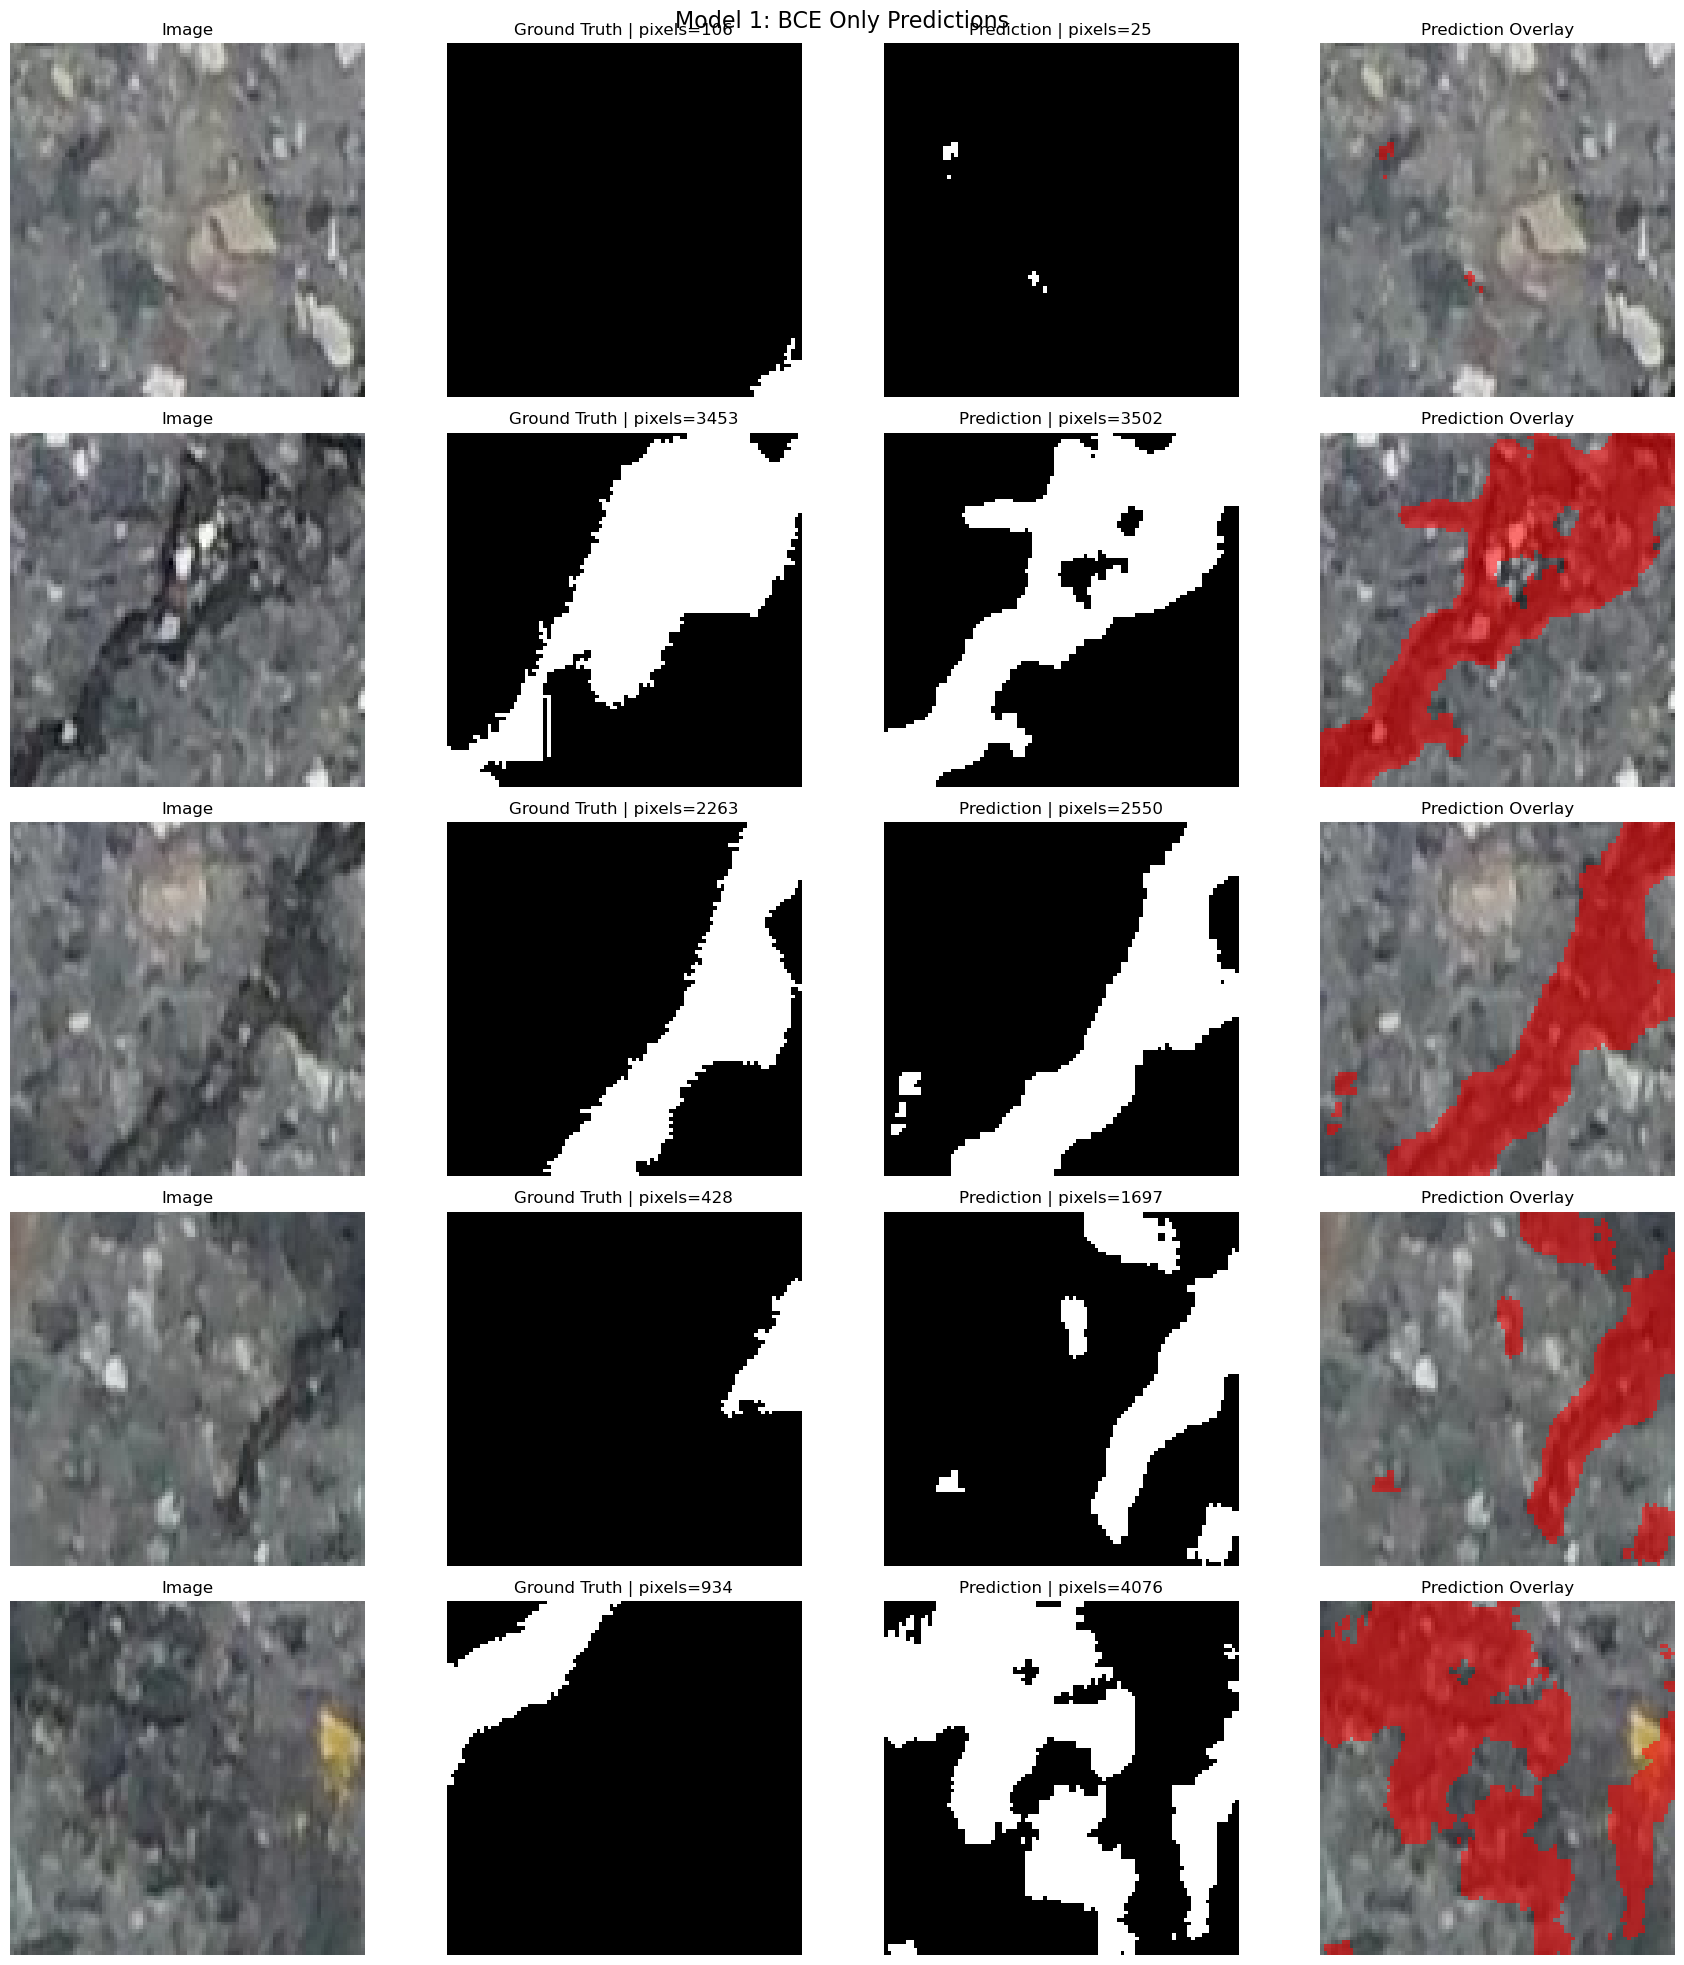

In [17]:
# ============================================================
# STEP 11C: Visualize Model 1 Predictions — BCE Only
# ============================================================
# Goal:
# 1. Visualize test patches with meaningful crack pixels.
# 2. Show image, ground truth, prediction, and overlay.
# 3. Avoid blank/empty masks in visualization.
# ============================================================

def get_complex_crack_batch(loader, min_crack_pixels=50, max_samples=5):
    """
    Select samples from the test loader that contain enough crack pixels.
    This avoids visualizing blank masks.
    """

    selected_images = []
    selected_masks = []

    for images, masks in loader:
        for i in range(images.shape[0]):
            crack_pixels = masks[i, 0].sum().item()

            if crack_pixels >= min_crack_pixels:
                selected_images.append(images[i])
                selected_masks.append(masks[i])

            if len(selected_images) >= max_samples:
                return (
                    torch.stack(selected_images),
                    torch.stack(selected_masks)
                )

    return (
        torch.stack(selected_images),
        torch.stack(selected_masks)
    )


def visualize_model_predictions(
    model,
    threshold_module,
    loader,
    device,
    num_samples=5,
    min_crack_pixels=50,
    title="Model Predictions"
):
    """
    Visualize predictions:
        image | ground truth | prediction | overlay
    """

    model.eval()
    threshold_module.eval()

    images, masks = get_complex_crack_batch(
        loader,
        min_crack_pixels=min_crack_pixels,
        max_samples=num_samples
    )

    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        threshold = threshold_module()
        preds = (probs > threshold).float()

    num_samples = min(num_samples, images.shape[0])

    fig, axes = plt.subplots(num_samples, 4, figsize=(18, 4 * num_samples))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        image_np = images[i].cpu().permute(1, 2, 0).numpy()
        mask_np = masks[i, 0].cpu().numpy()
        pred_np = preds[i, 0].cpu().numpy()

        # Prediction overlay in red
        overlay = image_np.copy()
        red_layer = np.zeros_like(overlay)
        red_layer[:, :, 0] = 1.0

        alpha = 0.55
        overlay = np.where(
            pred_np[..., None] == 1,
            (1 - alpha) * overlay + alpha * red_layer,
            overlay
        )

        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title(f"Ground Truth | pixels={int(mask_np.sum())}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_np, cmap="gray")
        axes[i, 2].set_title(f"Prediction | pixels={int(pred_np.sum())}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Prediction Overlay")
        axes[i, 3].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_model_predictions(
    model=model_1_best,
    threshold_module=threshold_1_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=50,
    title="Model 1: BCE Only Predictions"
)

In [18]:
# ============================================================
# STEP 12: Train Model 2 — BCE + SATLoss Creators Only
# ============================================================
# Model:
#     BCE + SATLoss creators only
#
# Goal:
# 1. Train crack segmentation model using BCE plus creators-only SATLoss.
# 2. BCE learns pixel-wise crack/background classification.
# 3. Creators-only SATLoss encourages better topological creator points.
# 4. Save best model using validation Dice.
# ============================================================

model_2_results = train_model(
    config_key="bce_sat_creators",
    config=model_configs["bce_sat_creators"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 2 training completed.")
print("Best model path:", model_2_results["best_model_path"])
print("Best threshold path:", model_2_results["best_threshold_path"])
print("Best validation Dice:", model_2_results["best_val_dice"])


Training model: BCE + SATLoss creators only

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:19<00:00, 35.91it/s]


Train Total Loss       : 0.3175
Train BCE Loss         : 0.2484
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.1132
Train Foreground Loss  : 0.0638
Train Threshold Loss   : 0.5517
Learned Threshold      : 0.3234
Val BCE Loss           : 0.2328
Val Accuracy           : 0.8993
Val Dice               : 0.5573
Val clDice             : 0.5107
Val beta0 err          : 1.4839
Val beta1 err          : 0.1502
Val Threshold          : 0.3234
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:20<00:00, 35.46it/s]


Train Total Loss       : 0.2842
Train BCE Loss         : 0.2224
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.1324
Train Foreground Loss  : 0.0559
Train Threshold Loss   : 0.4928
Learned Threshold      : 0.3305
Val BCE Loss           : 0.2313
Val Accuracy           : 0.8908
Val Dice               : 0.5921
Val clDice             : 0.5615
Val beta0 err          : 1.9370
Val beta1 err          : 0.1516
Val Threshold          : 0.3305
Best model updated and saved.

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.2506
Train BCE Loss         : 0.1955
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.1687
Train Foreground Loss  : 0.0475
Train Threshold Loss   : 0.4390
Learned Threshold      : 0.3553
Val BCE Loss           : 0.1997
Val Accuracy           : 0.9173
Val Dice               : 0.6273
Val clDice             : 0.5990
Val beta0 err          : 1.1787
Val beta1 err          : 0.1119
Val Threshold          : 0.3553

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:20<00:00, 34.39it/s]


Train Total Loss       : 0.2502
Train BCE Loss         : 0.1952
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.1689
Train Foreground Loss  : 0.0474
Train Threshold Loss   : 0.4382
Learned Threshold      : 0.3560
Val BCE Loss           : 0.2151
Val Accuracy           : 0.8954
Val Dice               : 0.6222
Val clDice             : 0.5986
Val beta0 err          : 1.6340
Val beta1 err          : 0.1796
Val Threshold          : 0.3560

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:20<00:00, 35.50it/s]

Train Total Loss       : 0.2498
Train BCE Loss         : 0.1949
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.1689
Train Foreground Loss  : 0.0471
Train Threshold Loss   : 0.4374
Learned Threshold      : 0.3568
Val BCE Loss           : 0.2179
Val Accuracy           : 0.8947
Val Dice               : 0.6223
Val clDice             : 0.5984
Val beta0 err          : 1.5551
Val beta1 err          : 0.1812
Val Threshold          : 0.3568

Training finished: BCE + SATLoss creators only
Best validation Dice: 0.6314305967280082

Model 2 training completed.
Best model path: saved_models/best_bce_sat_creators.pth
Best threshold path: saved_models/best_bce_sat_creators_threshold.pth
Best validation Dice: 0.6314305967280082


In [19]:
# ============================================================
# STEP 12B: Evaluate Model 2 — BCE + SATLoss Creators Only
# ============================================================

model_2_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_2_best = LearnableThreshold(init_value=0.5).to(device)

model_2_best.load_state_dict(
    torch.load(model_2_results["best_model_path"], map_location=device)
)

threshold_2_best.load_state_dict(
    torch.load(model_2_results["best_threshold_path"], map_location=device)
)

model_2_test_metrics = evaluate_model(
    model=model_2_best,
    threshold_module=threshold_2_best,
    loader=test_loader,
    device=device
)

print("=" * 70)
print("MODEL 2 TEST RESULTS: BCE + SATLoss Creators Only")
print("=" * 70)
print(f"Test BCE Loss  : {model_2_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_2_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_2_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_2_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_2_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_2_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_2_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:19<00:00, 35.53it/s]

MODEL 2 TEST RESULTS: BCE + SATLoss Creators Only
Test BCE Loss  : 0.2129
Test Accuracy  : 0.9061
Test Dice      : 0.6283
Test clDice    : 0.5949
Test beta0 err : 1.5852
Test beta1 err : 0.1564
Threshold      : 0.3535


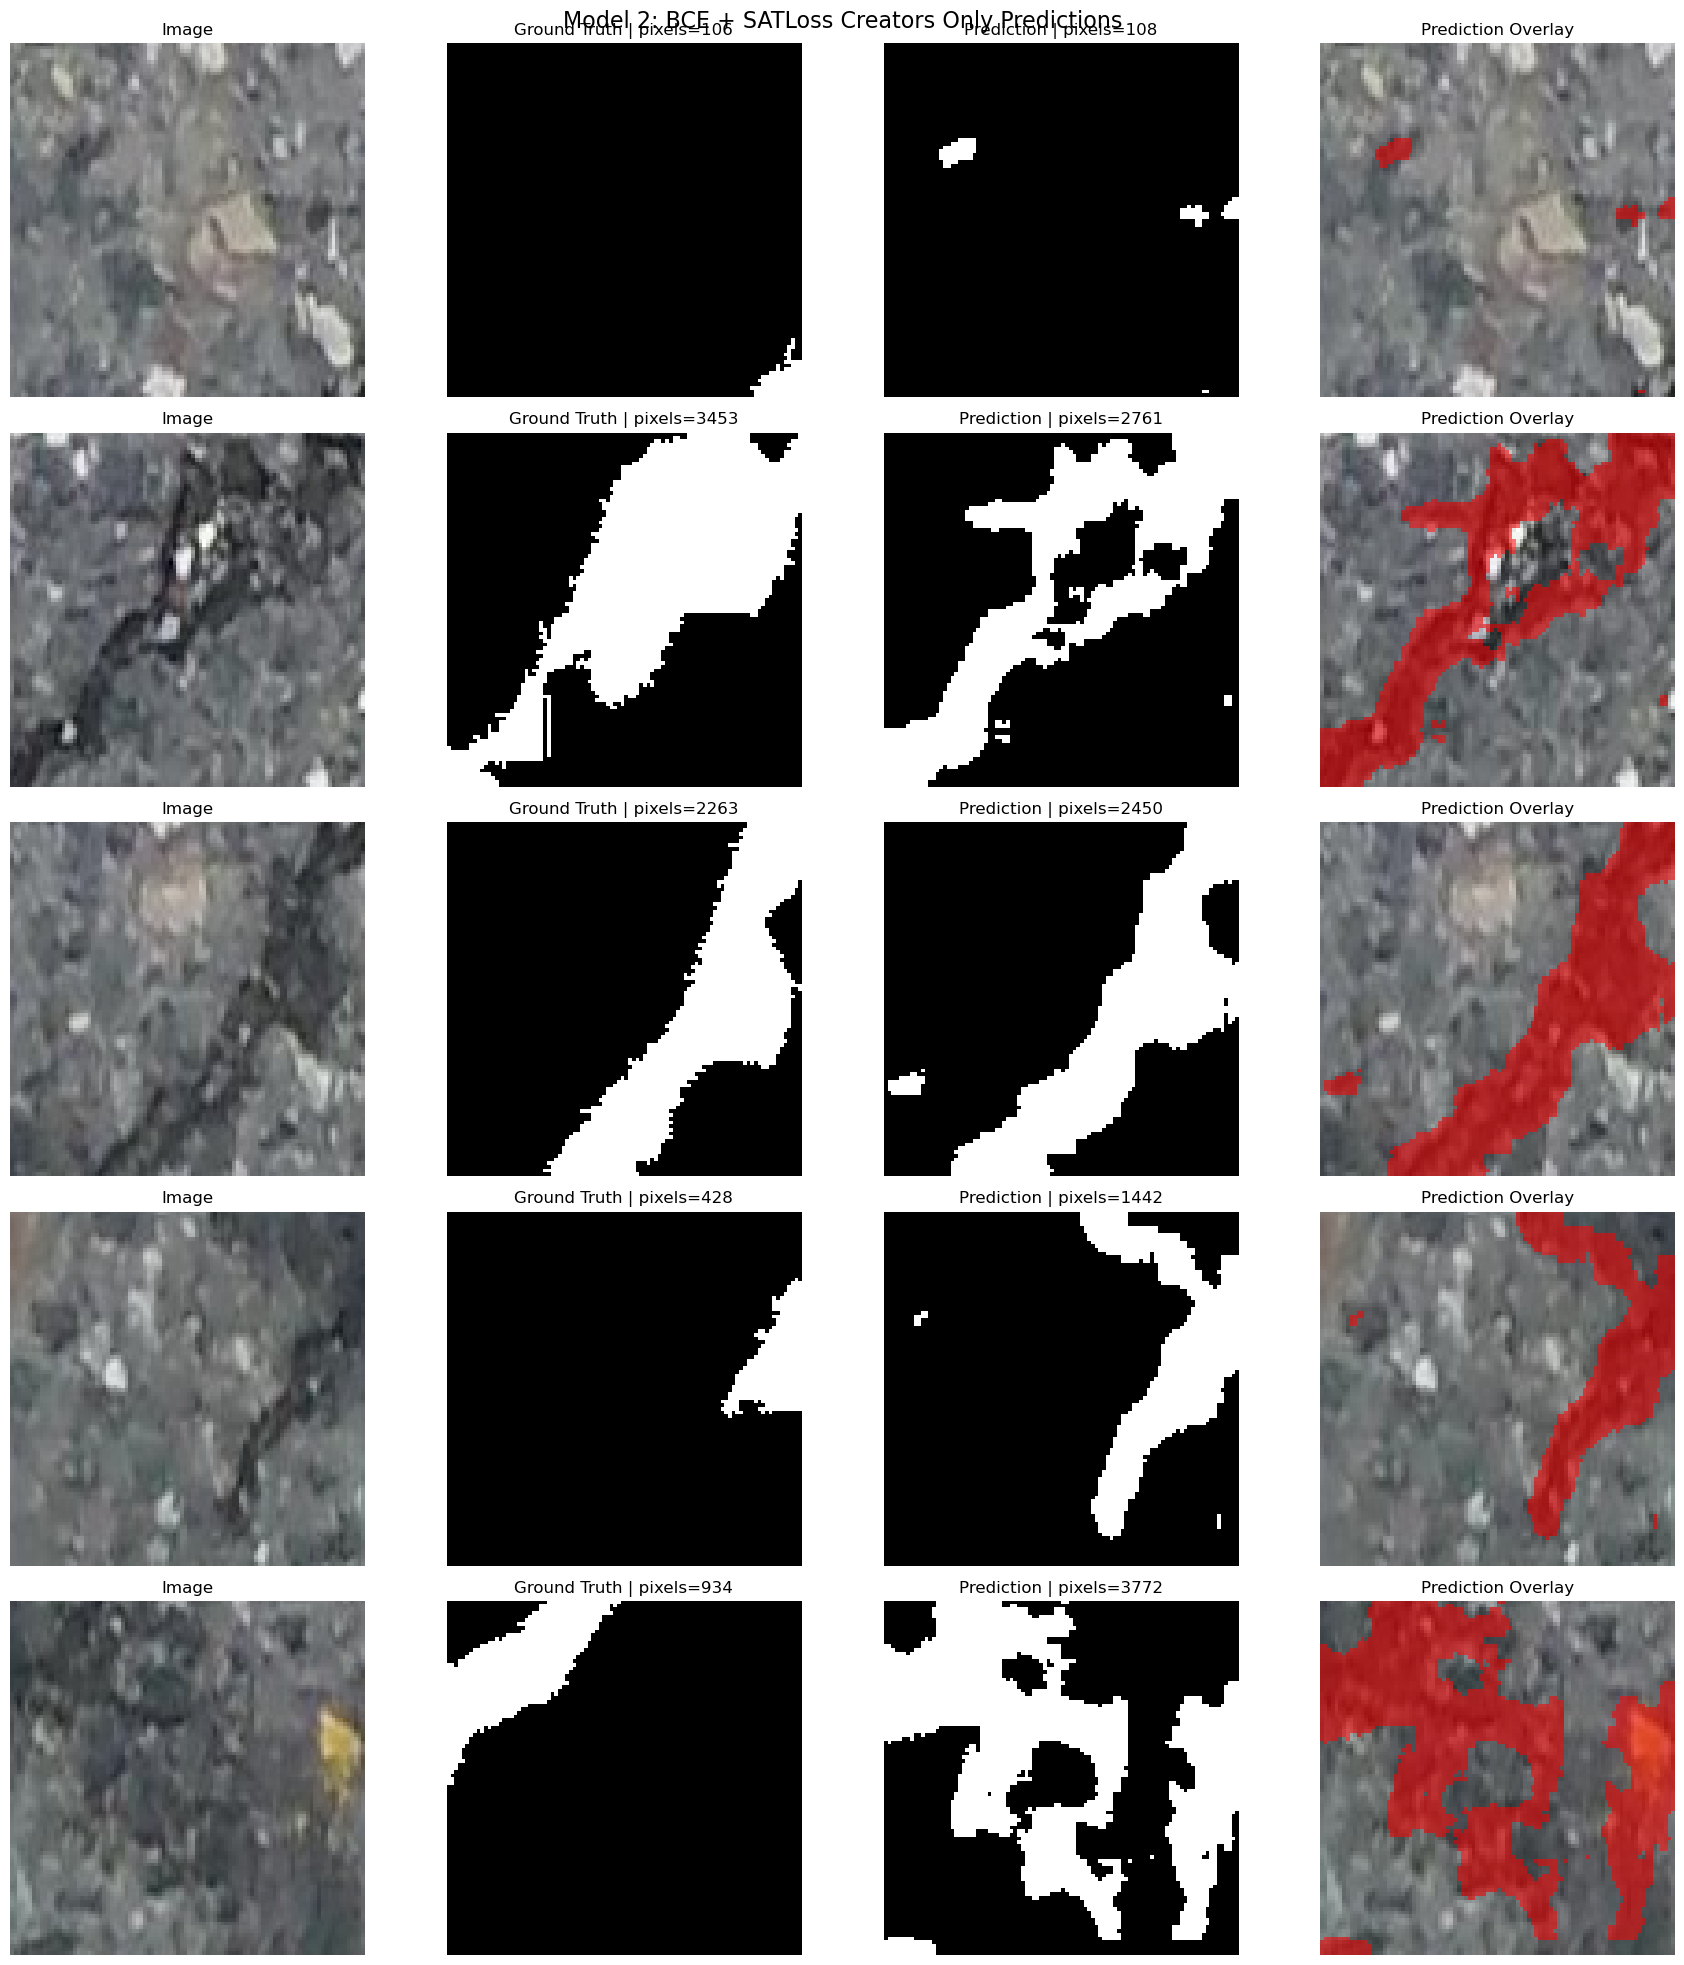

In [20]:
# ============================================================
# STEP 12C: Visualize Model 2 Predictions
# ============================================================

visualize_model_predictions(
    model=model_2_best,
    threshold_module=threshold_2_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=50,
    title="Model 2: BCE + SATLoss Creators Only Predictions"
)

In [21]:
# ============================================================
# STEP 13: Train Model 3 — BCE + SATLoss Creators + Destroyers
# ============================================================
# Model:
#     BCE + SATLoss creators + destroyers
#
# Goal:
# 1. Train crack segmentation model using BCE plus creator-destroyer SATLoss.
# 2. BCE learns pixel-wise crack/background classification.
# 3. Creator-destroyer SATLoss encourages better topology by using both
#    birth and death points of persistence features.
# 4. Save best model using validation Dice.
# ============================================================

model_3_results = train_model(
    config_key="bce_sat_creators_destroyers",
    config=model_configs["bce_sat_creators_destroyers"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 3 training completed.")
print("Best model path:", model_3_results["best_model_path"])
print("Best threshold path:", model_3_results["best_threshold_path"])
print("Best validation Dice:", model_3_results["best_val_dice"])


Training model: BCE + SATLoss creators + destroyers

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:24<00:00, 28.75it/s]


Train Total Loss       : 0.3205
Train BCE Loss         : 0.2514
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0430
Train Foreground Loss  : 0.0648
Train Threshold Loss   : 0.5570
Learned Threshold      : 0.3258
Val BCE Loss           : 0.2338
Val Accuracy           : 0.9083
Val Dice               : 0.5555
Val clDice             : 0.5118
Val beta0 err          : 1.4888
Val beta1 err          : 0.1144
Val Threshold          : 0.3258
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:32<00:00, 21.87it/s]


Train Total Loss       : 0.2840
Train BCE Loss         : 0.2229
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0481
Train Foreground Loss  : 0.0561
Train Threshold Loss   : 0.4945
Learned Threshold      : 0.3354
Val BCE Loss           : 0.2278
Val Accuracy           : 0.9060
Val Dice               : 0.5874
Val clDice             : 0.5543
Val beta0 err          : 1.5656
Val beta1 err          : 0.1207
Val Threshold          : 0.3354
Best model updated and saved.

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.2482
Train BCE Loss         : 0.1945
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0548
Train Foreground Loss  : 0.0469
Train Threshold Loss   : 0.4372
Learned Threshold      : 0.3584
Val BCE Loss           : 0.2023
Val Accuracy           : 0.9112
Val Dice               : 0.6286
Val clDice             : 0.5994
Val beta0 err          : 1.3559
Val beta1 err          : 0.1329
Val Threshold          : 0.3584

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:28<00:00, 25.04it/s]


Train Total Loss       : 0.2485
Train BCE Loss         : 0.1948
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0550
Train Foreground Loss  : 0.0472
Train Threshold Loss   : 0.4368
Learned Threshold      : 0.3582
Val BCE Loss           : 0.2006
Val Accuracy           : 0.9119
Val Dice               : 0.6307
Val clDice             : 0.5984
Val beta0 err          : 1.6273
Val beta1 err          : 0.1333
Val Threshold          : 0.3582

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:28<00:00, 24.73it/s]

Train Total Loss       : 0.2477
Train BCE Loss         : 0.1942
Train Dice Loss        : 0.0000
Train soft-clDice Loss : 0.0000
Train SATLoss          : 0.0562
Train Foreground Loss  : 0.0471
Train Threshold Loss   : 0.4361
Learned Threshold      : 0.3591
Val BCE Loss           : 0.2165
Val Accuracy           : 0.8940
Val Dice               : 0.6212
Val clDice             : 0.5964
Val beta0 err          : 1.5054
Val beta1 err          : 0.1887
Val Threshold          : 0.3591

Training finished: BCE + SATLoss creators + destroyers
Best validation Dice: 0.6318277424865669

Model 3 training completed.
Best model path: saved_models/best_bce_sat_creators_destroyers.pth
Best threshold path: saved_models/best_bce_sat_creators_destroyers_threshold.pth
Best validation Dice: 0.6318277424865669


In [22]:
# ============================================================
# STEP 13B: Evaluate Model 3 — BCE + SATLoss Creators + Destroyers
# ============================================================

model_3_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_3_best = LearnableThreshold(init_value=0.5).to(device)

model_3_best.load_state_dict(
    torch.load(model_3_results["best_model_path"], map_location=device)
)

threshold_3_best.load_state_dict(
    torch.load(model_3_results["best_threshold_path"], map_location=device)
)

model_3_test_metrics = evaluate_model(
    model=model_3_best,
    threshold_module=threshold_3_best,
    loader=test_loader,
    device=device
)

print("=" * 80)
print("MODEL 3 TEST RESULTS: BCE + SATLoss Creators + Destroyers")
print("=" * 80)
print(f"Test BCE Loss  : {model_3_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_3_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_3_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_3_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_3_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_3_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_3_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:28<00:00, 24.74it/s]

MODEL 3 TEST RESULTS: BCE + SATLoss Creators + Destroyers
Test BCE Loss  : 0.2130
Test Accuracy  : 0.9055
Test Dice      : 0.6268
Test clDice    : 0.5973
Test beta0 err : 1.3941
Test beta1 err : 0.1313
Threshold      : 0.3570


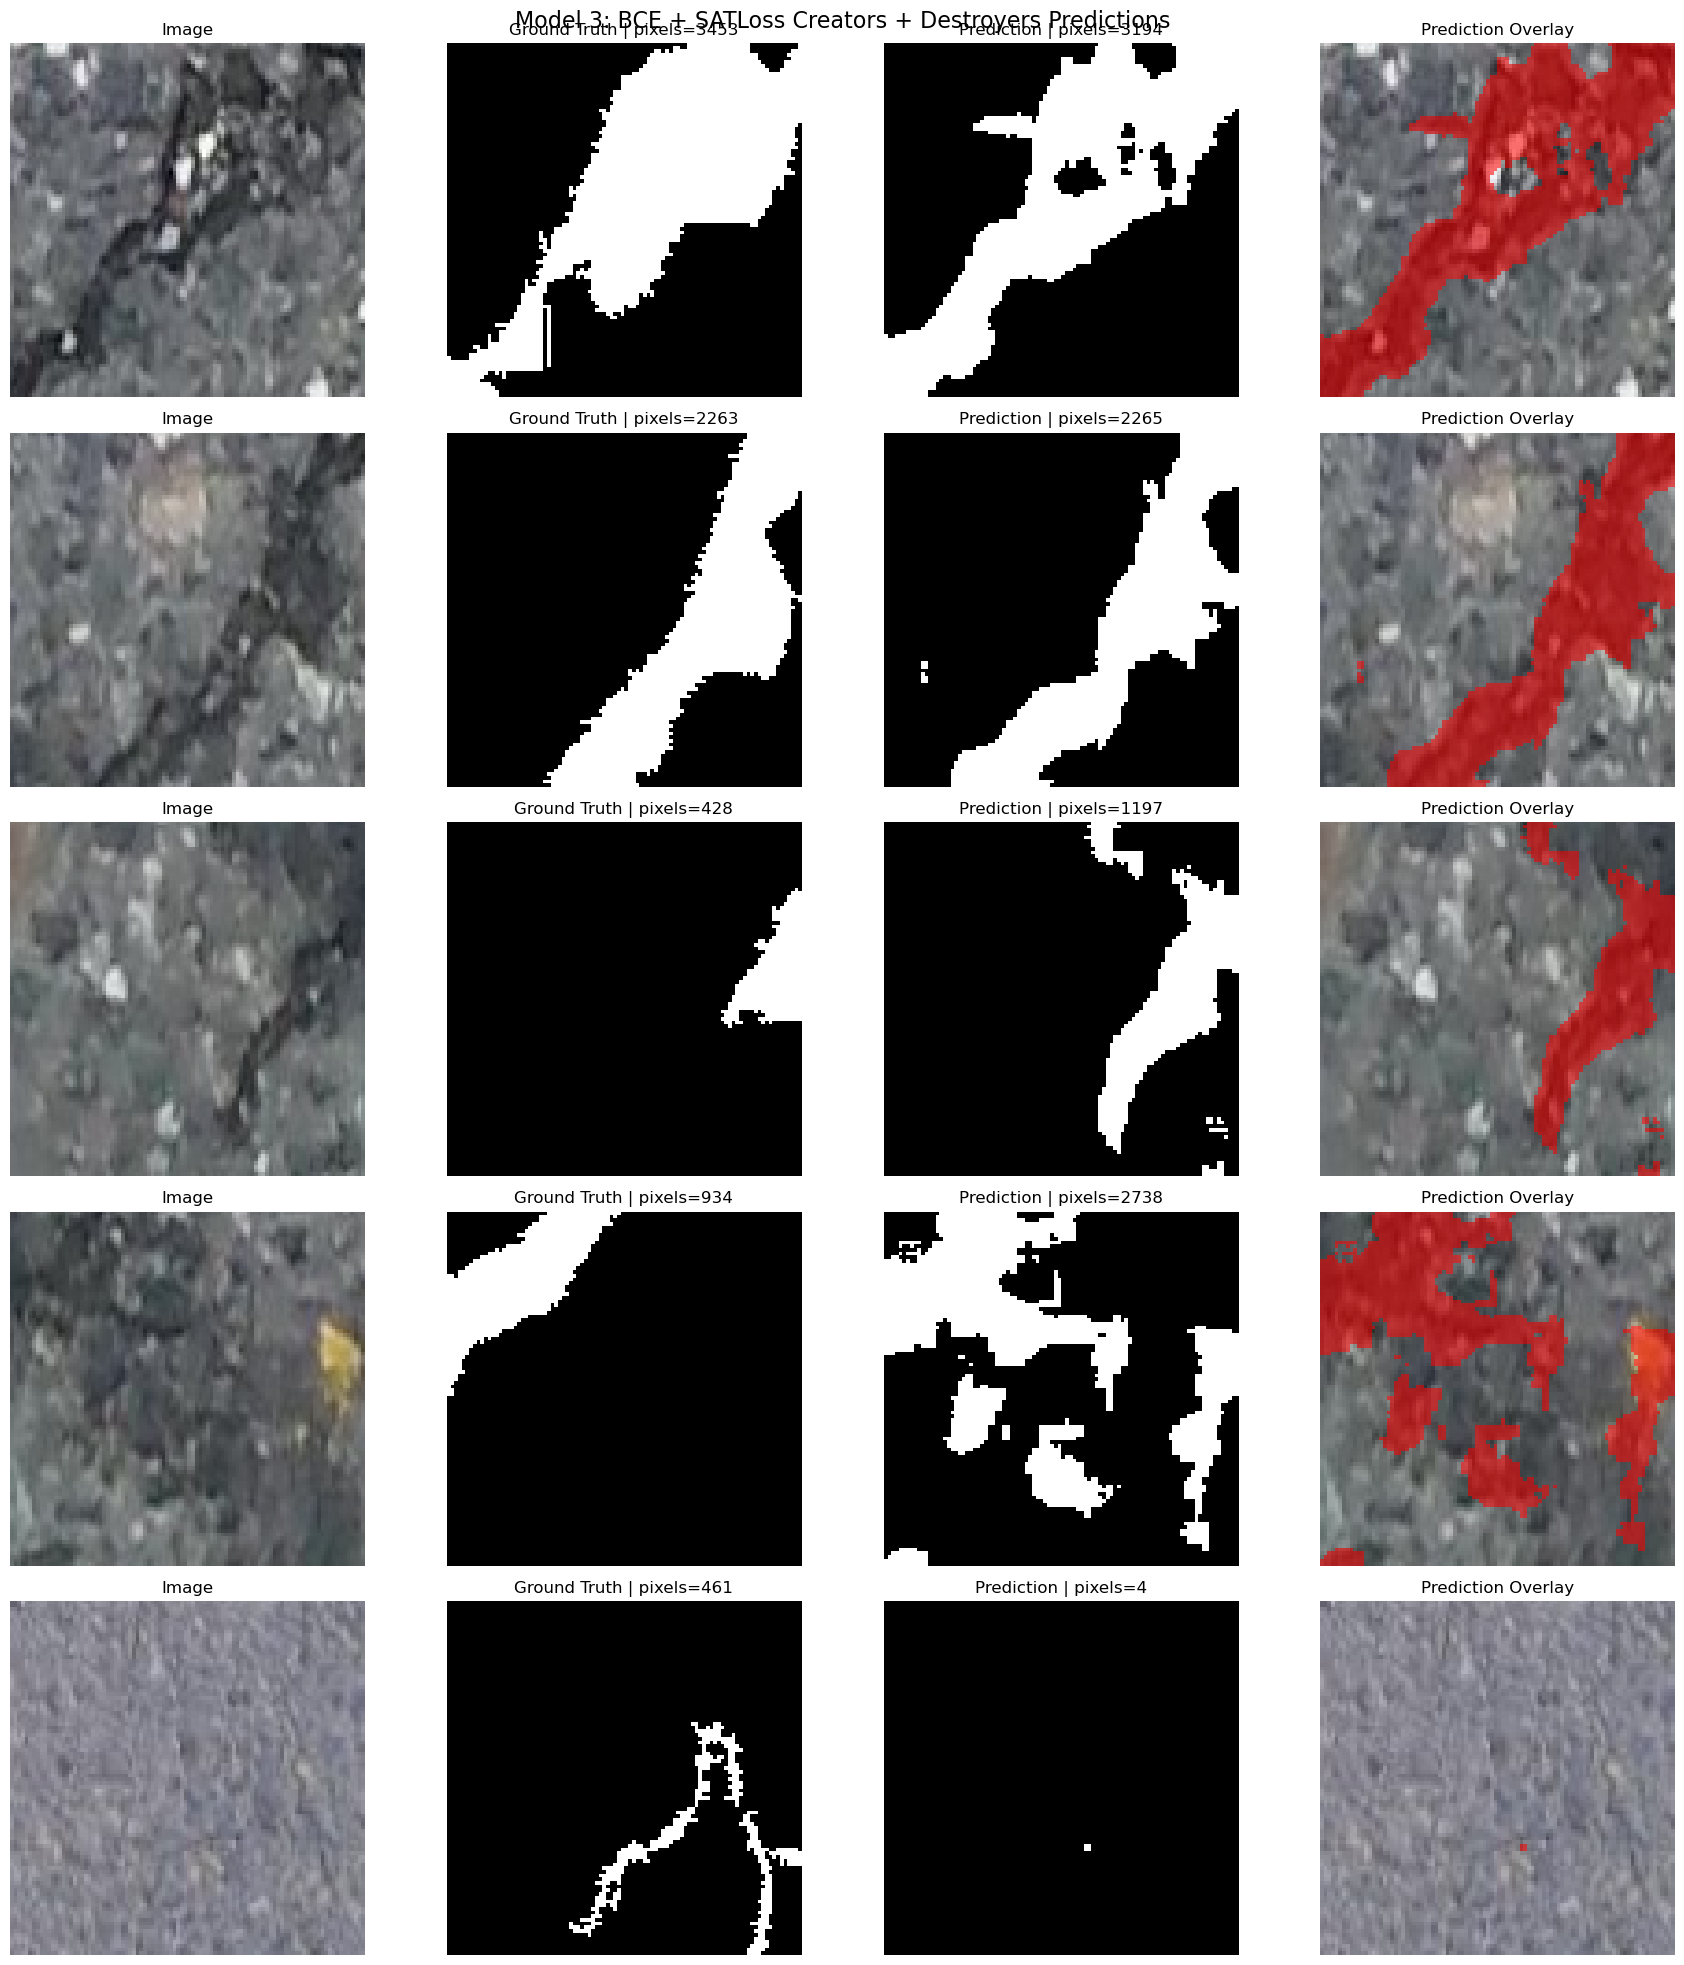

In [23]:
# ============================================================
# STEP 13C: Visualize Model 3 Predictions
# ============================================================

visualize_model_predictions(
    model=model_3_best,
    threshold_module=threshold_3_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=150,
    title="Model 3: BCE + SATLoss Creators + Destroyers Predictions"
)

In [24]:
# ============================================================
# STEP 14: Train Model 4 — BCE + Dice + clDice
# ============================================================
# Model:
#     BCE + Dice + clDice
#
# Goal:
# 1. Train hybrid crack segmentation model without SATLoss.
# 2. BCE learns pixel-wise crack/background classification.
# 3. Dice improves crack-mask overlap.
# 4. clDice improves crack connectivity.
# 5. Save best model using validation Dice.
# ============================================================

model_4_results = train_model(
    config_key="hybrid_bce_dice_cldice",
    config=model_configs["hybrid_bce_dice_cldice"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 4 training completed.")
print("Best model path:", model_4_results["best_model_path"])
print("Best threshold path:", model_4_results["best_threshold_path"])
print("Best validation Dice:", model_4_results["best_val_dice"])


Training model: BCE + Dice + clDice

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:29<00:00, 24.18it/s]


Train Total Loss       : 0.8806
Train BCE Loss         : 0.2631
Train Dice Loss        : 0.5879
Train soft-clDice Loss : 0.5145
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0745
Train Threshold Loss   : 0.5137
Learned Threshold      : 0.4647
Val BCE Loss           : 0.2434
Val Accuracy           : 0.8973
Val Dice               : 0.6115
Val clDice             : 0.6374
Val beta0 err          : 0.7716
Val beta1 err          : 0.0750
Val Threshold          : 0.4647
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:29<00:00, 24.27it/s]


Train Total Loss       : 0.7163
Train BCE Loss         : 0.2174
Train Dice Loss        : 0.4891
Train soft-clDice Loss : 0.4006
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0572
Train Threshold Loss   : 0.4260
Learned Threshold      : 0.5358
Val BCE Loss           : 0.2096
Val Accuracy           : 0.9123
Val Dice               : 0.6533
Val clDice             : 0.6892
Val beta0 err          : 0.4657
Val beta1 err          : 0.0530
Val Threshold          : 0.5358
Best model updated and saved.

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.5780
Train BCE Loss         : 0.1794
Train Dice Loss        : 0.4079
Train soft-clDice Loss : 0.3001
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0456
Train Threshold Loss   : 0.3551
Learned Threshold      : 0.5777
Val BCE Loss           : 0.1809
Val Accuracy           : 0.9267
Val Dice               : 0.7051
Val clDice             : 0.7459
Val beta0 err          : 0.3288
Val beta1 err          : 0.0488
Val Threshold          : 0.5777

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:22<00:00, 31.55it/s]


Train Total Loss       : 0.5762
Train BCE Loss         : 0.1789
Train Dice Loss        : 0.4066
Train soft-clDice Loss : 0.2992
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0454
Train Threshold Loss   : 0.3541
Learned Threshold      : 0.5773
Val BCE Loss           : 0.1762
Val Accuracy           : 0.9305
Val Dice               : 0.7054
Val clDice             : 0.7320
Val beta0 err          : 0.3386
Val beta1 err          : 0.0530
Val Threshold          : 0.5773

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 715/715 [00:22<00:00, 31.21it/s]


Train Total Loss       : 0.5751
Train BCE Loss         : 0.1785
Train Dice Loss        : 0.4056
Train soft-clDice Loss : 0.2988
Train SATLoss          : 0.0000
Train Foreground Loss  : 0.0454
Train Threshold Loss   : 0.3534
Learned Threshold      : 0.5781
Val BCE Loss           : 0.1741
Val Accuracy           : 0.9312
Val Dice               : 0.7108
Val clDice             : 0.7397
Val beta0 err          : 0.3391
Val beta1 err          : 0.0483
Val Threshold          : 0.5781
Best model updated and saved.

Training finished: BCE + Dice + clDice
Best validation Dice: 0.7108244286758917

Model 4 training completed.
Best model path: saved_models/best_hybrid_bce_dice_cldice.pth
Best threshold path: saved_models/best_hybrid_bce_dice_cldice_threshold.pth
Best validation Dice: 0.7108244286758917


In [25]:
# ============================================================
# STEP 14B: Evaluate Model 4 — BCE + Dice + clDice
# ============================================================

model_4_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_4_best = LearnableThreshold(init_value=0.5).to(device)

model_4_best.load_state_dict(
    torch.load(model_4_results["best_model_path"], map_location=device)
)

threshold_4_best.load_state_dict(
    torch.load(model_4_results["best_threshold_path"], map_location=device)
)

model_4_test_metrics = evaluate_model(
    model=model_4_best,
    threshold_module=threshold_4_best,
    loader=test_loader,
    device=device
)

print("=" * 70)
print("MODEL 4 TEST RESULTS: BCE + Dice + clDice")
print("=" * 70)
print(f"Test BCE Loss  : {model_4_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_4_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_4_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_4_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_4_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_4_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_4_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:22<00:00, 31.08it/s]

MODEL 4 TEST RESULTS: BCE + Dice + clDice
Test BCE Loss  : 0.1812
Test Accuracy  : 0.9295
Test Dice      : 0.7127
Test clDice    : 0.7410
Test beta0 err : 0.3251
Test beta1 err : 0.0498
Threshold      : 0.5781


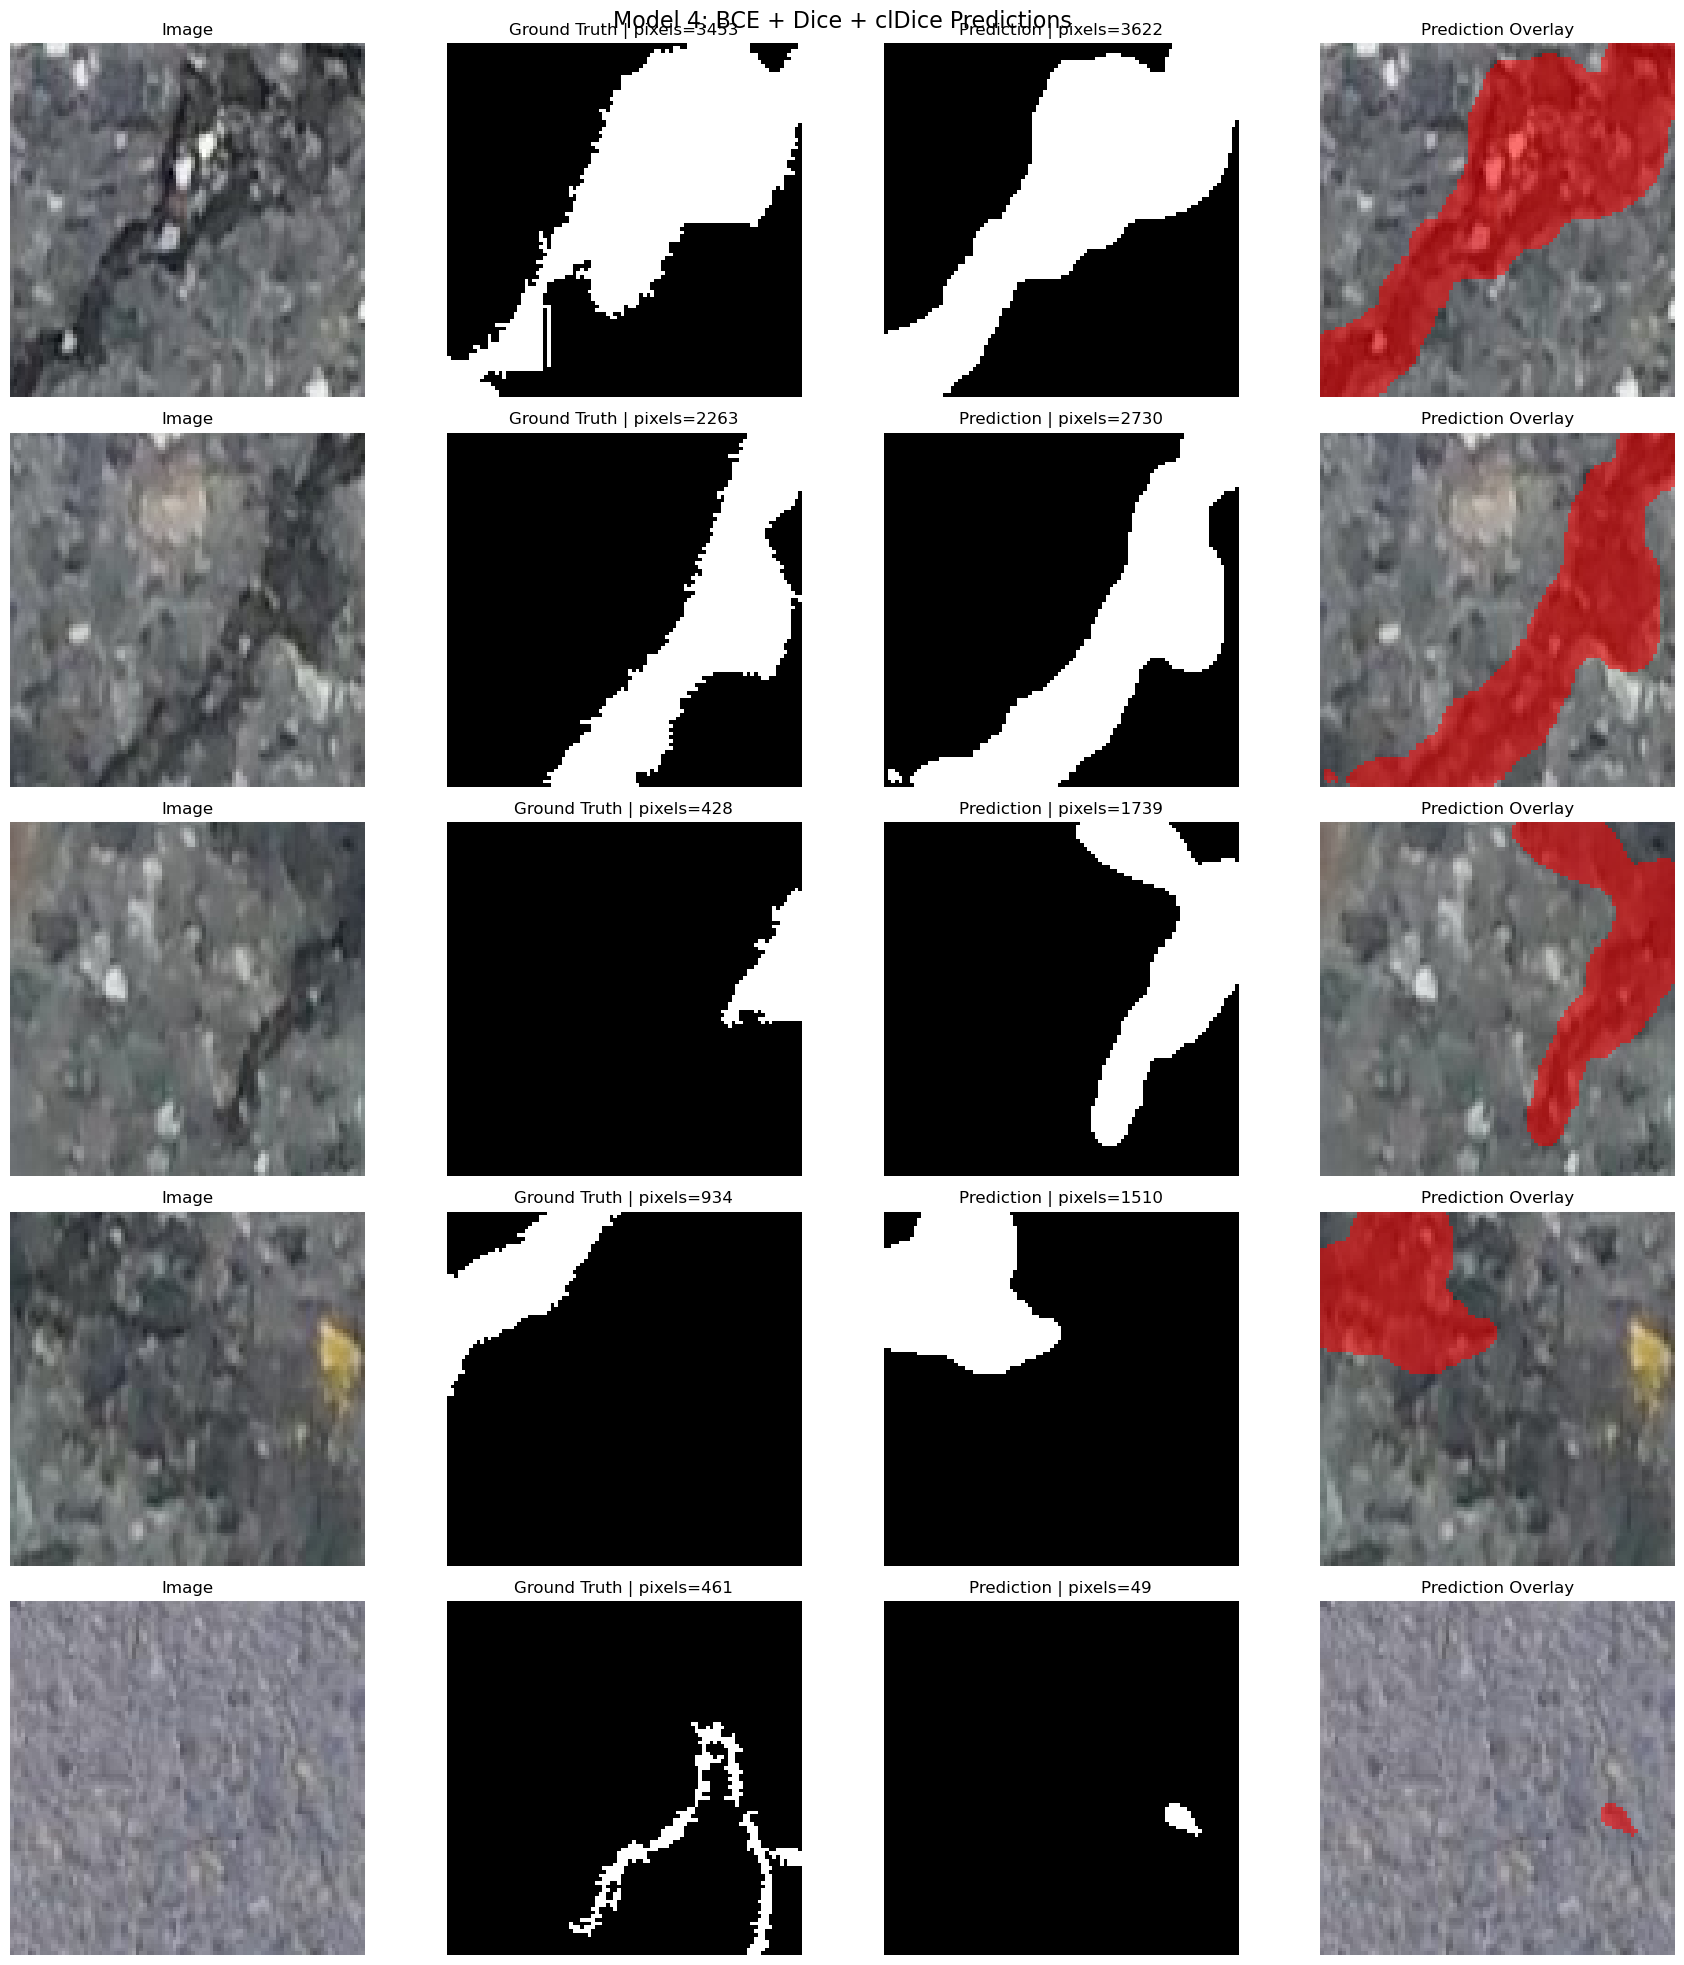

In [26]:
# ============================================================
# STEP 14C: Visualize Model 4 Predictions
# ============================================================

visualize_model_predictions(
    model=model_4_best,
    threshold_module=threshold_4_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=150,
    title="Model 4: BCE + Dice + clDice Predictions"
)

In [27]:
# ============================================================
# STEP 15: Train Model 5 — BCE + Dice + clDice + SATLoss Creators Only
# ============================================================
# Model:
#     BCE + Dice + clDice + SATLoss creators only
#
# Goal:
# 1. Train topology-aware hybrid crack segmentation model.
# 2. BCE learns pixel-wise crack/background classification.
# 3. Dice improves mask overlap.
# 4. clDice improves crack connectivity.
# 5. Creators-only SATLoss improves topological birth/creator features.
# 6. Save best model using validation Dice.
# ============================================================

model_5_results = train_model(
    config_key="hybrid_sat_creators",
    config=model_configs["hybrid_sat_creators"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 5 training completed.")
print("Best model path:", model_5_results["best_model_path"])
print("Best threshold path:", model_5_results["best_threshold_path"])
print("Best validation Dice:", model_5_results["best_val_dice"])


Training model: BCE + Dice + clDice + SATLoss creators only

Epoch 1/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators only: 100%|██████████| 3295/3295 [13:44<00:00,  4.00it/s]
Evaluating: 100%|██████████| 715/715 [00:19<00:00, 35.83it/s]


Train Total Loss       : 0.8956
Train BCE Loss         : 0.2643
Train Dice Loss        : 0.5965
Train soft-clDice Loss : 0.5267
Train SATLoss          : 0.2756
Train Foreground Loss  : 0.0739
Train Threshold Loss   : 0.5208
Learned Threshold      : 0.4378
Val BCE Loss           : 0.2692
Val Accuracy           : 0.8827
Val Dice               : 0.5753
Val clDice             : 0.5869
Val beta0 err          : 1.9767
Val beta1 err          : 0.1249
Val Threshold          : 0.4378
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators only: 100%|██████████| 3295/3295 [11:38<00:00,  4.72it/s]
Evaluating: 100%|██████████| 715/715 [00:19<00:00, 35.82it/s]


Train Total Loss       : 0.8156
Train BCE Loss         : 0.2417
Train Dice Loss        : 0.5460
Train soft-clDice Loss : 0.4762
Train SATLoss          : 0.2452
Train Foreground Loss  : 0.0646
Train Threshold Loss   : 0.4749
Learned Threshold      : 0.4558
Val BCE Loss           : 0.2345
Val Accuracy           : 0.9130
Val Dice               : 0.5605
Val clDice             : 0.5509
Val beta0 err          : 1.2417
Val beta1 err          : 0.0673
Val Threshold          : 0.4558

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.7189
Train BCE Loss         : 0.2141
Train Dice Loss        : 0.4882
Train soft-clDice Loss : 0.4109
Train SATLoss          : 0.1965
Train Foreground Loss  : 0.0549
Train Threshold Loss   : 0.4238
Learned Threshold      : 0.4922
Val BCE Loss           : 0.2238
Val Accuracy           : 0.9064
Val Dice               : 0.6361
Val clDice             : 0.6534
Val beta0 err          : 1.2873
Val beta1 err          : 0.0846
Val Threshold          : 0.4922
Best model updated and saved.

Epoch 19/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators only: 100%|██████████| 3295/3295 [15:47<00:00,  3.48it/s]
Evaluating: 100%|██████████| 715/715 [00:24<00:00, 29.52it/s]


Train Total Loss       : 0.7190
Train BCE Loss         : 0.2143
Train Dice Loss        : 0.4880
Train soft-clDice Loss : 0.4107
Train SATLoss          : 0.1963
Train Foreground Loss  : 0.0549
Train Threshold Loss   : 0.4237
Learned Threshold      : 0.4926
Val BCE Loss           : 0.2309
Val Accuracy           : 0.9059
Val Dice               : 0.6306
Val clDice             : 0.6441
Val beta0 err          : 1.2966
Val beta1 err          : 0.0799
Val Threshold          : 0.4926

Epoch 20/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators only: 100%|██████████| 3295/3295 [17:40<00:00,  3.11it/s]
Evaluating: 100%|██████████| 715/715 [00:34<00:00, 20.52it/s]

Train Total Loss       : 0.7162
Train BCE Loss         : 0.2131
Train Dice Loss        : 0.4863
Train soft-clDice Loss : 0.4098
Train SATLoss          : 0.1964
Train Foreground Loss  : 0.0540
Train Threshold Loss   : 0.4223
Learned Threshold      : 0.4935
Val BCE Loss           : 0.2269
Val Accuracy           : 0.9059
Val Dice               : 0.6334
Val clDice             : 0.6478
Val beta0 err          : 1.1845
Val beta1 err          : 0.0789
Val Threshold          : 0.4935

Training finished: BCE + Dice + clDice + SATLoss creators only
Best validation Dice: 0.6361398846223638

Model 5 training completed.
Best model path: saved_models/best_hybrid_sat_creators.pth
Best threshold path: saved_models/best_hybrid_sat_creators_threshold.pth
Best validation Dice: 0.6361398846223638


In [28]:
# ============================================================
# STEP 15B: Evaluate Model 5 — BCE + Dice + clDice + SATLoss Creators Only
# ============================================================

model_5_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_5_best = LearnableThreshold(init_value=0.5).to(device)

model_5_best.load_state_dict(
    torch.load(model_5_results["best_model_path"], map_location=device)
)

threshold_5_best.load_state_dict(
    torch.load(model_5_results["best_threshold_path"], map_location=device)
)

model_5_test_metrics = evaluate_model(
    model=model_5_best,
    threshold_module=threshold_5_best,
    loader=test_loader,
    device=device
)

print("=" * 90)
print("MODEL 5 TEST RESULTS: BCE + Dice + clDice + SATLoss Creators Only")
print("=" * 90)
print(f"Test BCE Loss  : {model_5_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_5_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_5_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_5_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_5_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_5_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_5_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:33<00:00, 20.81it/s]

MODEL 5 TEST RESULTS: BCE + Dice + clDice + SATLoss Creators Only
Test BCE Loss  : 0.2309
Test Accuracy  : 0.9057
Test Dice      : 0.6332
Test clDice    : 0.6468
Test beta0 err : 1.2641
Test beta1 err : 0.0808
Threshold      : 0.4922


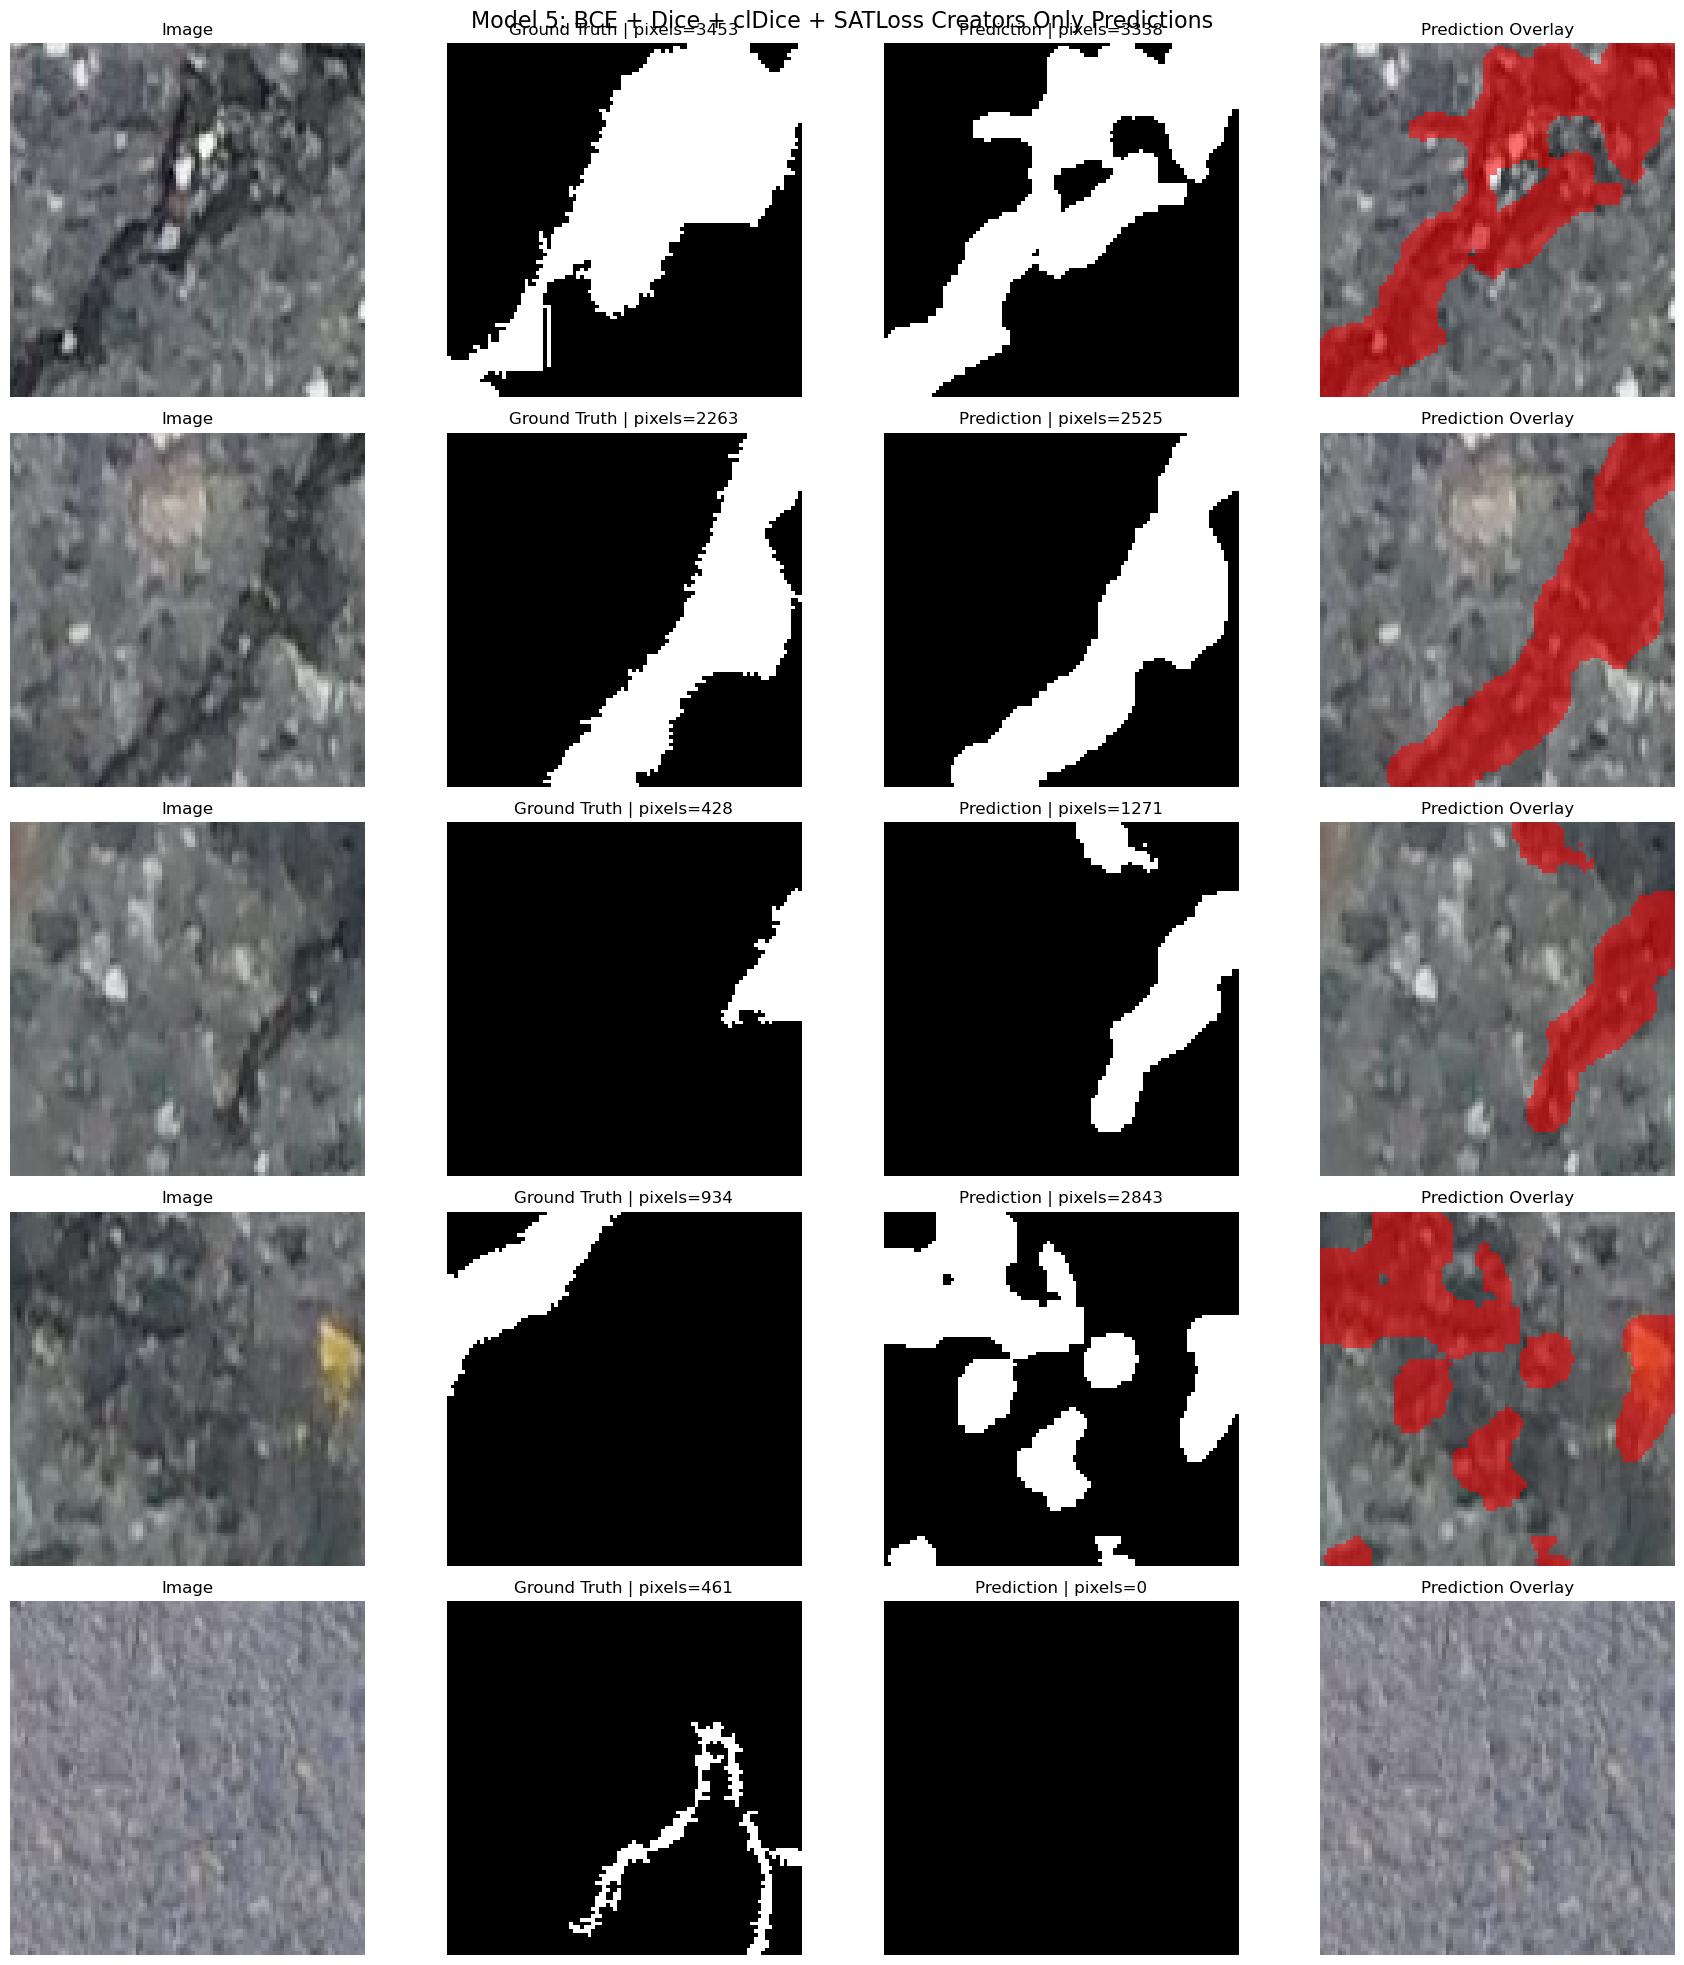

In [29]:
# ============================================================
# STEP 15C: Visualize Model 5 Predictions
# ============================================================

visualize_model_predictions(
    model=model_5_best,
    threshold_module=threshold_5_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=150,
    title="Model 5: BCE + Dice + clDice + SATLoss Creators Only Predictions"
)

In [30]:
# ============================================================
# STEP 16: Train Model 6 — BCE + Dice + clDice + SATLoss Creators + Destroyers
# ============================================================
# Model:
#     BCE + Dice + clDice + SATLoss creators + destroyers
#
# Goal:
# 1. Train the final topology-aware hybrid crack segmentation model.
# 2. BCE learns pixel-wise crack/background classification.
# 3. Dice improves mask overlap.
# 4. clDice improves crack connectivity.
# 5. Creator-destroyer SATLoss improves both birth and death topology features.
# 6. Save best model using validation Dice.
# ============================================================

model_6_results = train_model(
    config_key="hybrid_sat_creators_destroyers",
    config=model_configs["hybrid_sat_creators_destroyers"],
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

print("\nModel 6 training completed.")
print("Best model path:", model_6_results["best_model_path"])
print("Best threshold path:", model_6_results["best_threshold_path"])
print("Best validation Dice:", model_6_results["best_val_dice"])


Training model: BCE + Dice + clDice + SATLoss creators + destroyers

Epoch 1/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators + destroyers: 100%|██████████| 3295/3295 [24:00<00:00,  2.29it/s]
Evaluating: 100%|██████████| 715/715 [00:34<00:00, 20.56it/s]


Train Total Loss       : 0.8493
Train BCE Loss         : 0.2560
Train Dice Loss        : 0.5695
Train soft-clDice Loss : 0.4878
Train SATLoss          : 0.0561
Train Foreground Loss  : 0.0720
Train Threshold Loss   : 0.4973
Learned Threshold      : 0.4771
Val BCE Loss           : 0.2344
Val Accuracy           : 0.9105
Val Dice               : 0.6188
Val clDice             : 0.6249
Val beta0 err          : 0.7349
Val beta1 err          : 0.0649
Val Threshold          : 0.4771
Best model updated and saved.

Epoch 2/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators + destroyers: 100%|██████████| 3295/3295 [24:41<00:00,  2.22it/s]
Evaluating: 100%|██████████| 715/715 [00:35<00:00, 20.31it/s]


Train Total Loss       : 0.7509
Train BCE Loss         : 0.2279
Train Dice Loss        : 0.5112
Train soft-clDice Loss : 0.4197
Train SATLoss          : 0.0539
Train Foreground Loss  : 0.0617
Train Threshold Loss   : 0.4466
Learned Threshold      : 0.4991
Val BCE Loss           : 0.2218
Val Accuracy           : 0.9084
Val Dice               : 0.6135
Val clDice             : 0.6151
Val beta0 err          : 1.0934
Val beta1 err          : 0.0554
Val Threshold          : 0.4991

Epoch 3/20
--------------------------------------------------


...

Train Total Loss       : 0.6359
Train BCE Loss         : 0.1944
Train Dice Loss        : 0.4425
Train soft-clDice Loss : 0.3427
Train SATLoss          : 0.0507
Train Foreground Loss  : 0.0503
Train Threshold Loss   : 0.3840
Learned Threshold      : 0.5545
Val BCE Loss           : 0.1936
Val Accuracy           : 0.9229
Val Dice               : 0.6762
Val clDice             : 0.7032
Val beta0 err          : 0.5712
Val beta1 err          : 0.0523
Val Threshold          : 0.5545

Epoch 19/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators + destroyers: 100%|██████████| 3295/3295 [15:48<00:00,  3.47it/s]
Evaluating: 100%|██████████| 715/715 [00:20<00:00, 34.27it/s]


Train Total Loss       : 0.6344
Train BCE Loss         : 0.1935
Train Dice Loss        : 0.4417
Train soft-clDice Loss : 0.3423
Train SATLoss          : 0.0520
Train Foreground Loss  : 0.0499
Train Threshold Loss   : 0.3833
Learned Threshold      : 0.5555
Val BCE Loss           : 0.1907
Val Accuracy           : 0.9257
Val Dice               : 0.6749
Val clDice             : 0.6936
Val beta0 err          : 0.5747
Val beta1 err          : 0.0546
Val Threshold          : 0.5555

Epoch 20/20
--------------------------------------------------


Training BCE + Dice + clDice + SATLoss creators + destroyers: 100%|██████████| 3295/3295 [15:44<00:00,  3.49it/s]
Evaluating: 100%|██████████| 715/715 [00:21<00:00, 33.87it/s]


Train Total Loss       : 0.6325
Train BCE Loss         : 0.1931
Train Dice Loss        : 0.4402
Train soft-clDice Loss : 0.3413
Train SATLoss          : 0.0512
Train Foreground Loss  : 0.0497
Train Threshold Loss   : 0.3820
Learned Threshold      : 0.5551
Val BCE Loss           : 0.1915
Val Accuracy           : 0.9237
Val Dice               : 0.6799
Val clDice             : 0.7043
Val beta0 err          : 0.5768
Val beta1 err          : 0.0526
Val Threshold          : 0.5551
Best model updated and saved.

Training finished: BCE + Dice + clDice + SATLoss creators + destroyers
Best validation Dice: 0.6799306664850329

Model 6 training completed.
Best model path: saved_models/best_hybrid_sat_creators_destroyers.pth
Best threshold path: saved_models/best_hybrid_sat_creators_destroyers_threshold.pth
Best validation Dice: 0.6799306664850329


In [31]:
# ============================================================
# STEP 16B: Evaluate Model 6 — BCE + Dice + clDice + SATLoss Creators + Destroyers
# ============================================================

model_6_best = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=64
).to(device)

threshold_6_best = LearnableThreshold(init_value=0.5).to(device)

model_6_best.load_state_dict(
    torch.load(model_6_results["best_model_path"], map_location=device)
)

threshold_6_best.load_state_dict(
    torch.load(model_6_results["best_threshold_path"], map_location=device)
)

model_6_test_metrics = evaluate_model(
    model=model_6_best,
    threshold_module=threshold_6_best,
    loader=test_loader,
    device=device
)

print("=" * 100)
print("MODEL 6 TEST RESULTS: BCE + Dice + clDice + SATLoss Creators + Destroyers")
print("=" * 100)
print(f"Test BCE Loss  : {model_6_test_metrics['loss']:.4f}")
print(f"Test Accuracy  : {model_6_test_metrics['accuracy']:.4f}")
print(f"Test Dice      : {model_6_test_metrics['dice']:.4f}")
print(f"Test clDice    : {model_6_test_metrics['cldice']:.4f}")
print(f"Test beta0 err : {model_6_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err : {model_6_test_metrics['beta1_error']:.4f}")
print(f"Threshold      : {model_6_test_metrics['threshold']:.4f}")

Evaluating: 100%|██████████| 703/703 [00:21<00:00, 33.47it/s]

MODEL 6 TEST RESULTS: BCE + Dice + clDice + SATLoss Creators + Destroyers
Test BCE Loss  : 0.2043
Test Accuracy  : 0.9197
Test Dice      : 0.6752
Test clDice    : 0.7012
Test beta0 err : 0.5664
Test beta1 err : 0.0573
Threshold      : 0.5551


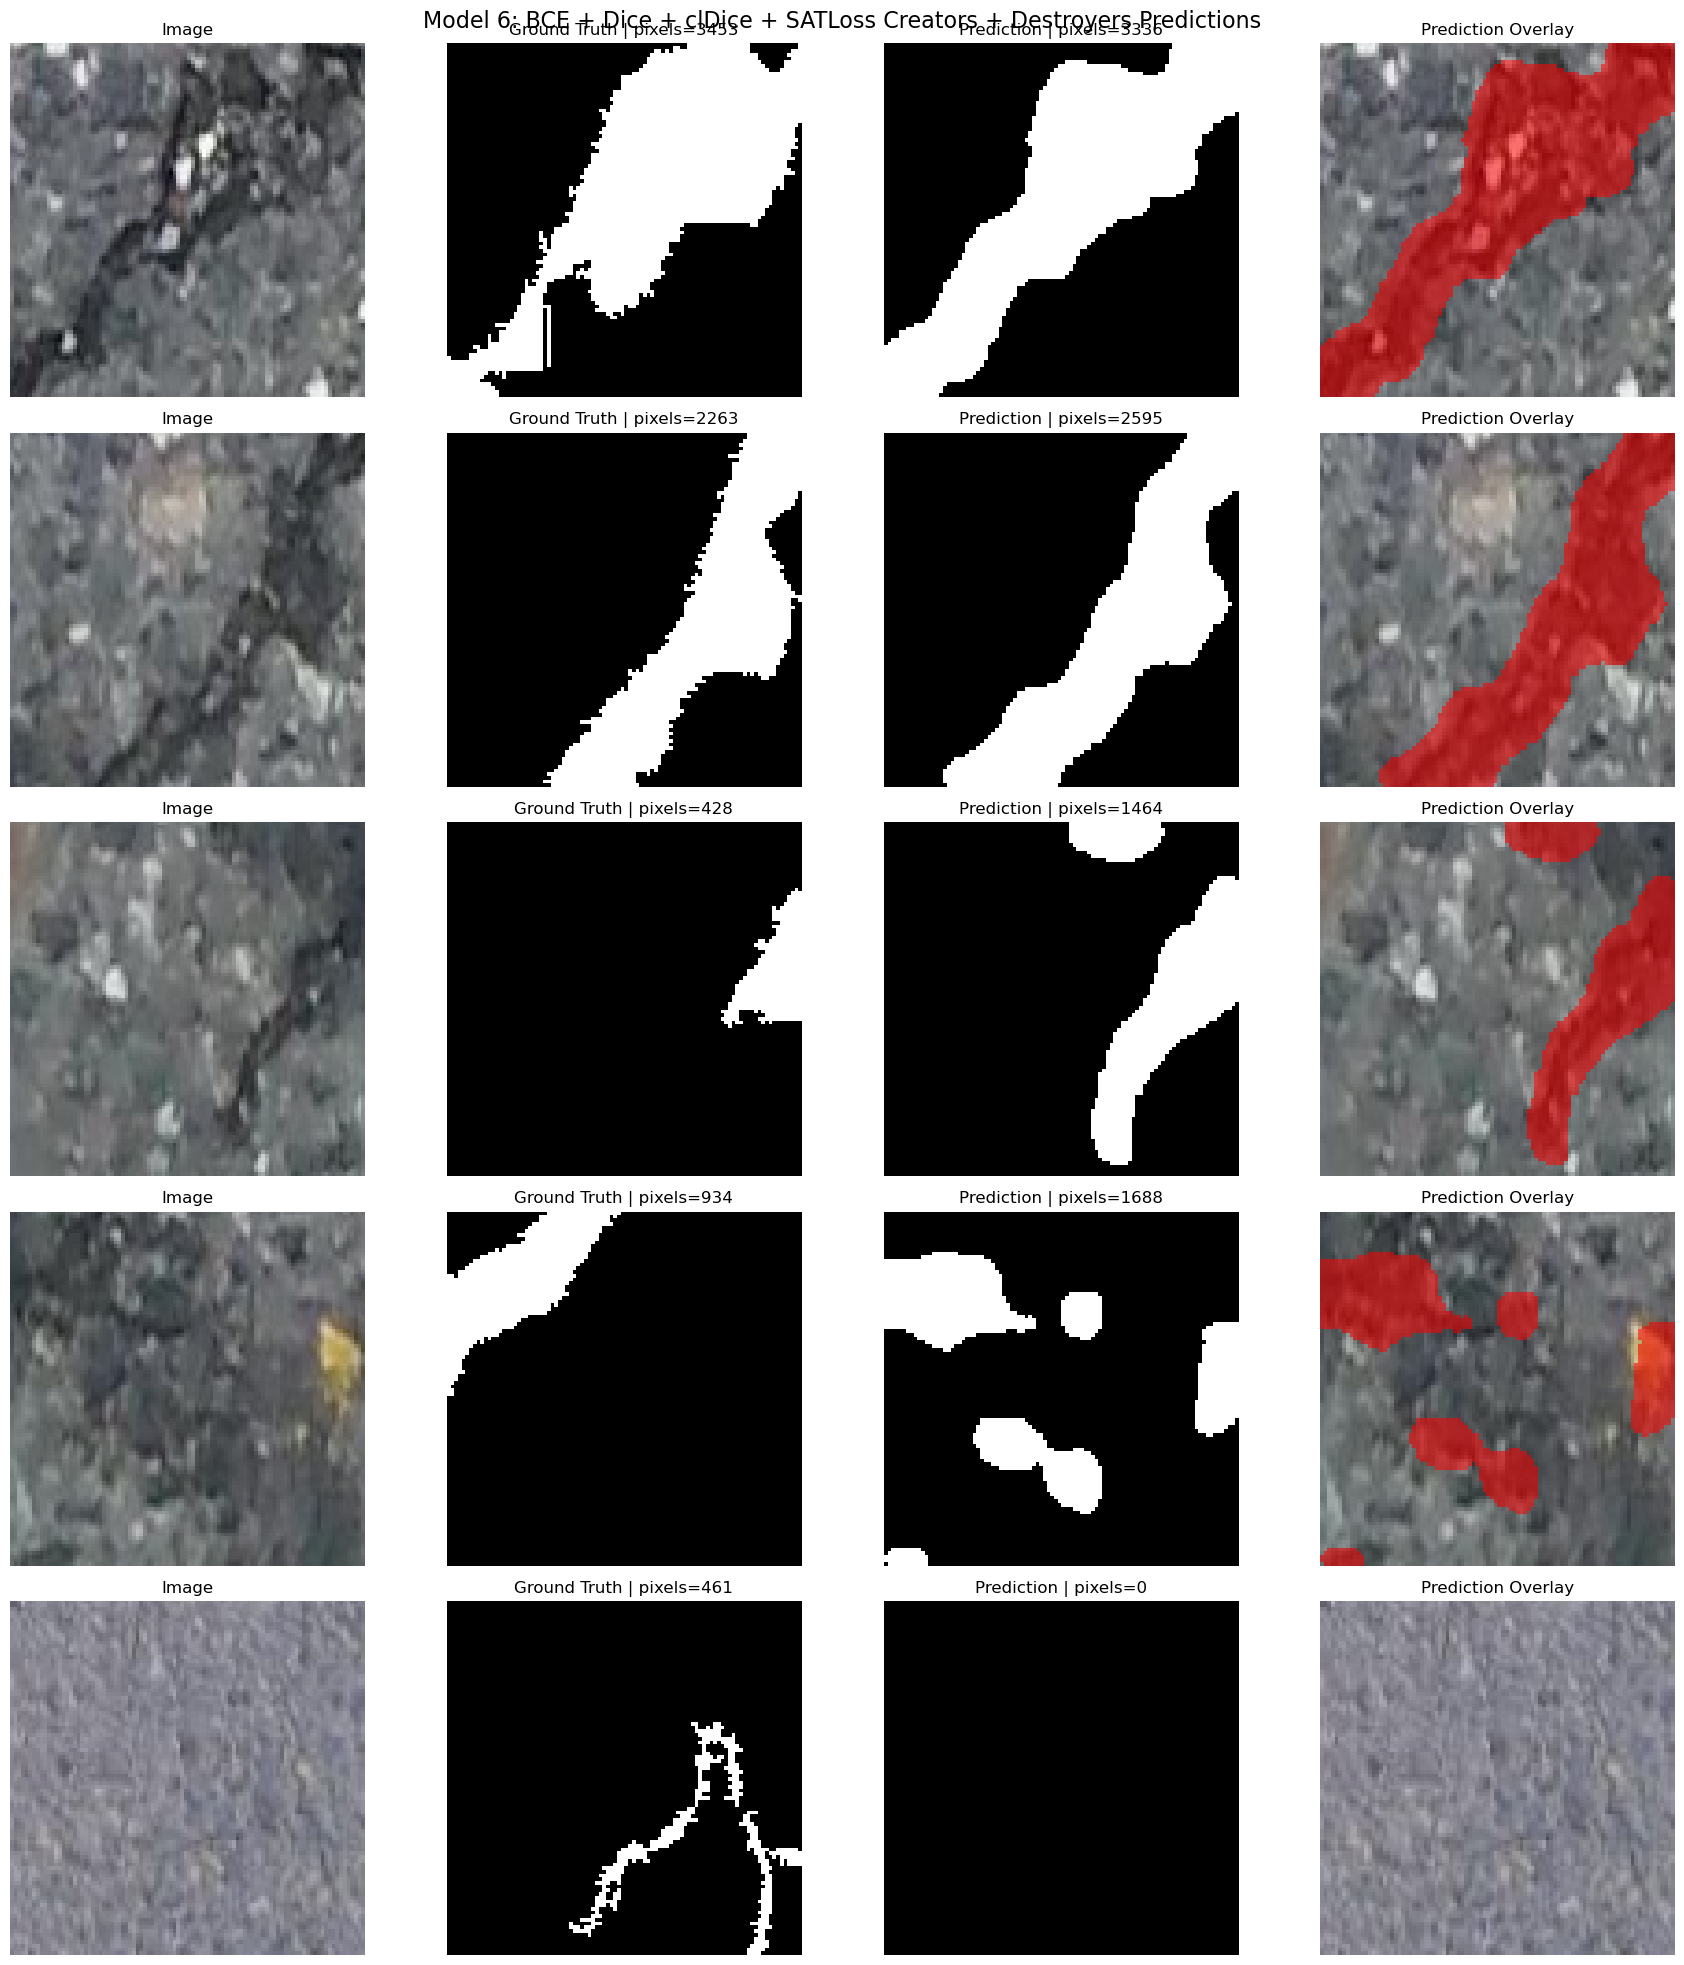

In [32]:
# ============================================================
# STEP 16C: Visualize Model 6 Predictions
# ============================================================

visualize_model_predictions(
    model=model_6_best,
    threshold_module=threshold_6_best,
    loader=test_loader,
    device=device,
    num_samples=5,
    min_crack_pixels=150,
    title="Model 6: BCE + Dice + clDice + SATLoss Creators + Destroyers Predictions"
)

In [34]:
# ============================================================
# STEP 17: Final Comparison Table for All 6 Models
# ============================================================
# Goal:
# 1. Collect test metrics from all trained models.
# 2. Compare pixel-wise performance and topology performance.
# 3. Save the final comparison table for thesis.
# ============================================================
import pandas as pd
results_table = [
    {
        "Model": "BCE only",
        "Accuracy": model_1_test_metrics["accuracy"],
        "Dice": model_1_test_metrics["dice"],
        "clDice": model_1_test_metrics["cldice"],
        "beta0_error": model_1_test_metrics["beta0_error"],
        "beta1_error": model_1_test_metrics["beta1_error"],
        "Threshold": model_1_test_metrics["threshold"]
    },
    {
        "Model": "BCE + SATLoss creators only",
        "Accuracy": model_2_test_metrics["accuracy"],
        "Dice": model_2_test_metrics["dice"],
        "clDice": model_2_test_metrics["cldice"],
        "beta0_error": model_2_test_metrics["beta0_error"],
        "beta1_error": model_2_test_metrics["beta1_error"],
        "Threshold": model_2_test_metrics["threshold"]
    },
    {
        "Model": "BCE + SATLoss creators + destroyers",
        "Accuracy": model_3_test_metrics["accuracy"],
        "Dice": model_3_test_metrics["dice"],
        "clDice": model_3_test_metrics["cldice"],
        "beta0_error": model_3_test_metrics["beta0_error"],
        "beta1_error": model_3_test_metrics["beta1_error"],
        "Threshold": model_3_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice",
        "Accuracy": model_4_test_metrics["accuracy"],
        "Dice": model_4_test_metrics["dice"],
        "clDice": model_4_test_metrics["cldice"],
        "beta0_error": model_4_test_metrics["beta0_error"],
        "beta1_error": model_4_test_metrics["beta1_error"],
        "Threshold": model_4_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice + SATLoss creators only",
        "Accuracy": model_5_test_metrics["accuracy"],
        "Dice": model_5_test_metrics["dice"],
        "clDice": model_5_test_metrics["cldice"],
        "beta0_error": model_5_test_metrics["beta0_error"],
        "beta1_error": model_5_test_metrics["beta1_error"],
        "Threshold": model_5_test_metrics["threshold"]
    },
    {
        "Model": "BCE + Dice + clDice + SATLoss creators + destroyers",
        "Accuracy": model_6_test_metrics["accuracy"],
        "Dice": model_6_test_metrics["dice"],
        "clDice": model_6_test_metrics["cldice"],
        "beta0_error": model_6_test_metrics["beta0_error"],
        "beta1_error": model_6_test_metrics["beta1_error"],
        "Threshold": model_6_test_metrics["threshold"]
    }
]

final_results_df = pd.DataFrame(results_table)

display(final_results_df)

final_results_df.to_csv("saved_results/final_model_comparison.csv", index=False)

print("Final comparison table saved to:")
print("saved_results/final_model_comparison.csv")

,Model,Accuracy,Dice,clDice,beta0_error,beta1_error,Threshold
0,BCE only,0.904154,0.630797,0.600223,1.744484,0.146085,0.361743
1,BCE + SATLoss creators only,0.906054,0.628301,0.594885,1.585231,0.156406,0.353522
2,BCE + SATLoss creators + destroyers,0.905514,0.626797,0.597254,1.394128,0.131317,0.356994
3,BCE + Dice + clDice,0.929500,0.712745,0.740997,0.325089,0.049822,0.578064
4,BCE + Dice + clDice + SATLoss creators only,0.905662,0.633189,0.646761,1.264057,0.080783,0.492168
5,BCE + Dice + clDice + SATLoss creators + destr...,0.919672,0.675168,0.701246,0.566370,0.057295,0.555140


Final comparison table saved to:
saved_results/final_model_comparison.csv


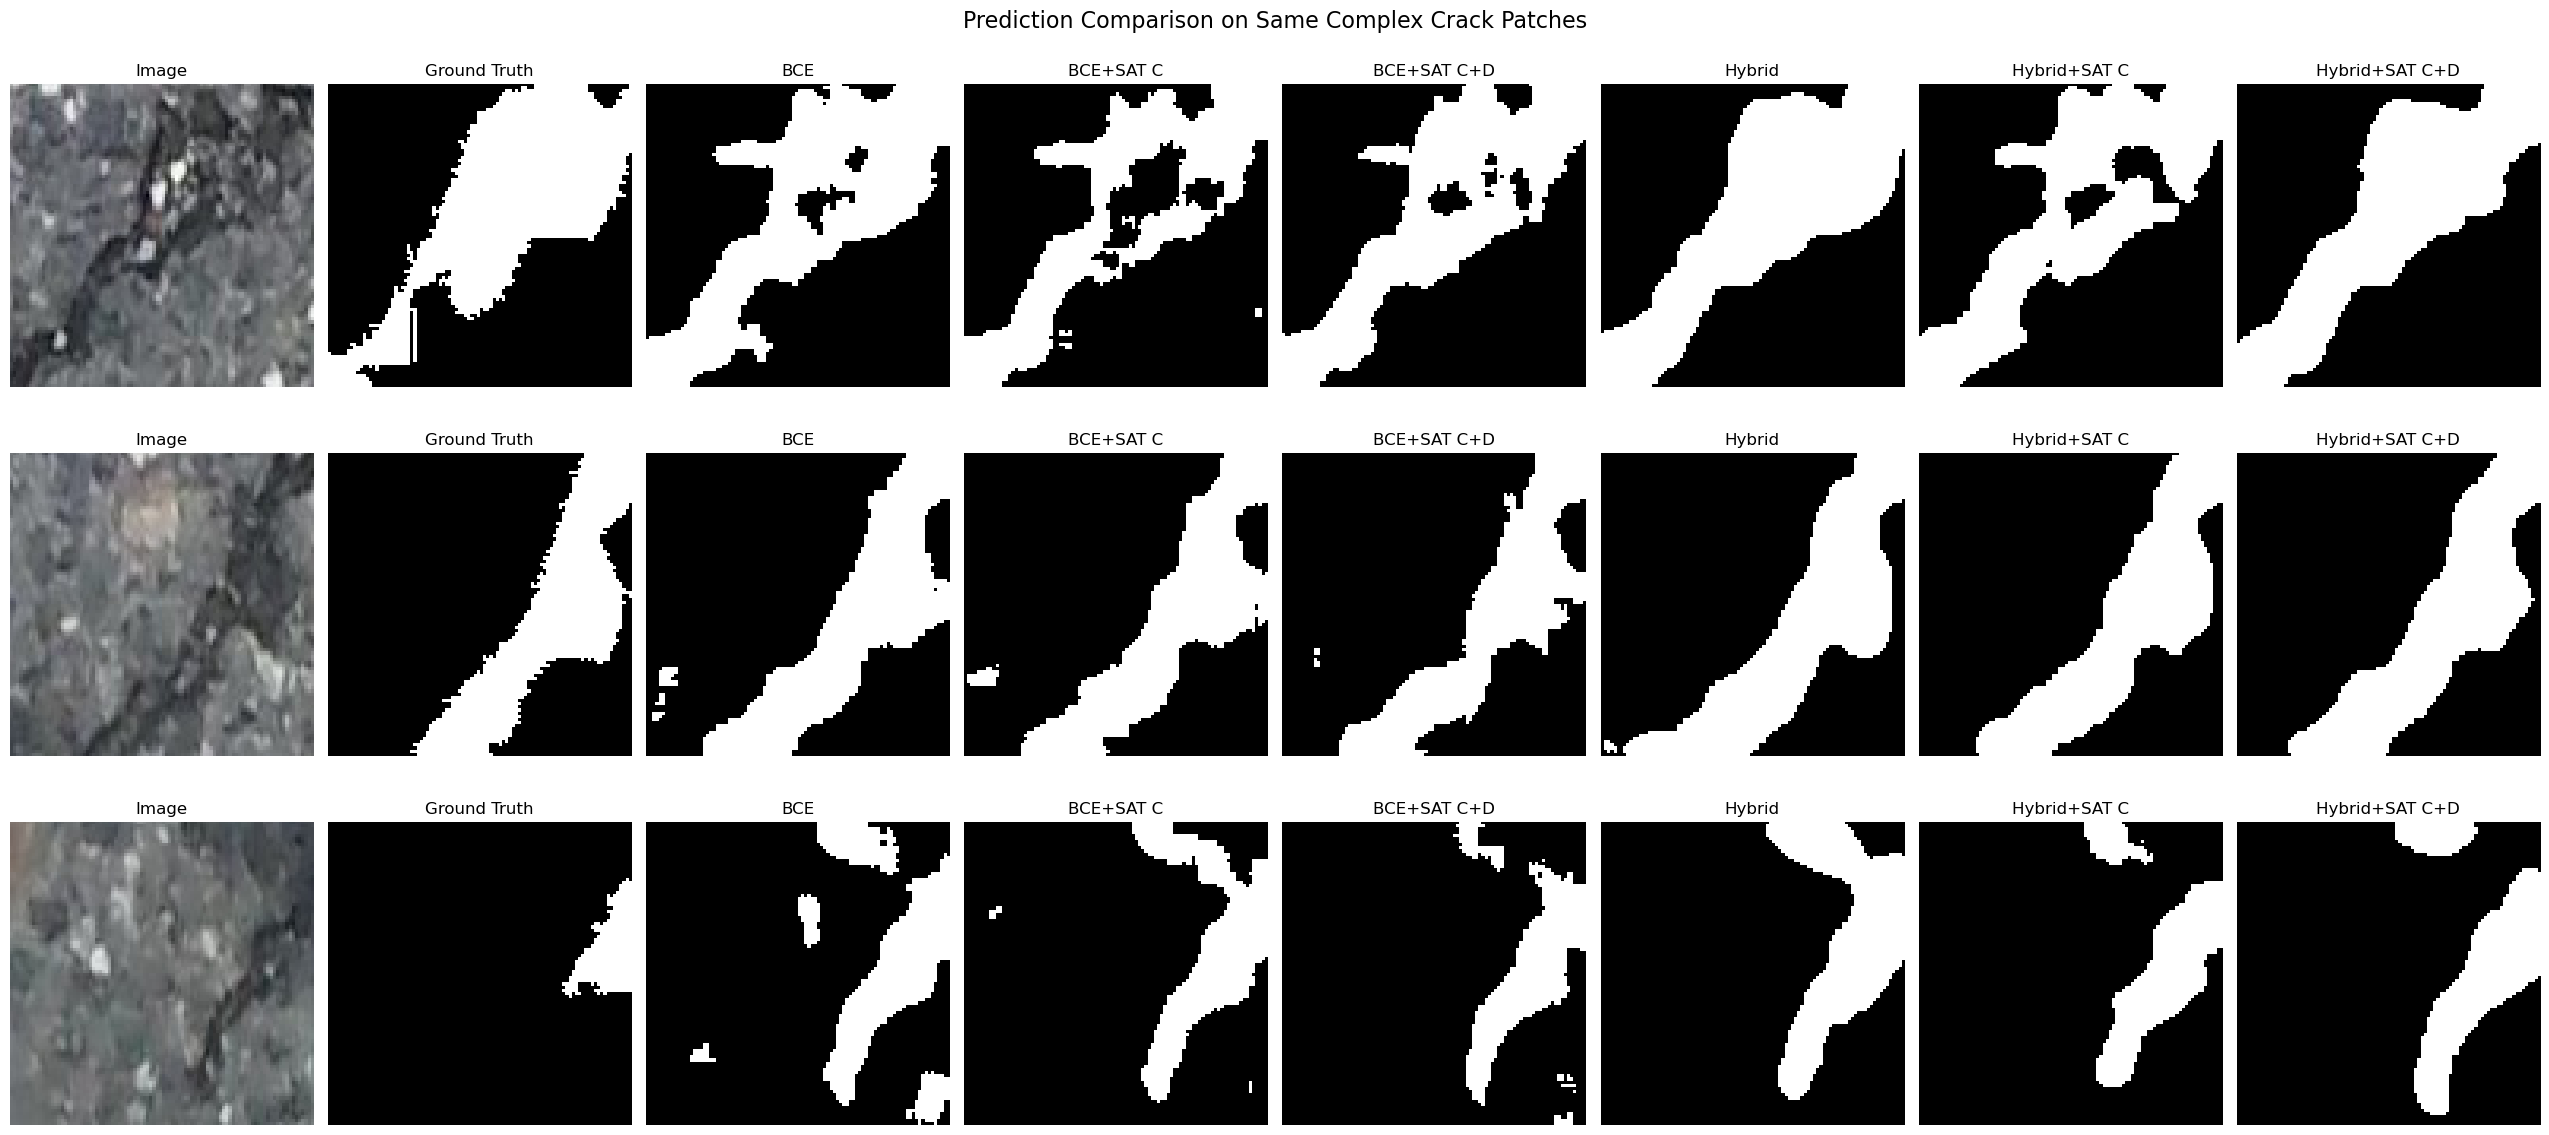

In [35]:
# ============================================================
# STEP 18: Visualize All 6 Models on the Same Complex Crack Samples
# ============================================================
# Goal:
# 1. Select the same complex crack patches from the test set.
# 2. Compare predictions from all six models fairly.
# 3. Show image, ground truth, and each model prediction.
# ============================================================

def get_fixed_complex_samples(loader, min_crack_pixels=150, num_samples=3):
    """
    Select fixed complex crack samples from the test loader.
    """

    selected_images = []
    selected_masks = []

    for images, masks in loader:
        for i in range(images.shape[0]):
            if masks[i, 0].sum().item() >= min_crack_pixels:
                selected_images.append(images[i])
                selected_masks.append(masks[i])

            if len(selected_images) >= num_samples:
                return torch.stack(selected_images), torch.stack(selected_masks)

    return torch.stack(selected_images), torch.stack(selected_masks)


def predict_binary(model, threshold_module, images, device):
    """
    Predict binary crack masks.
    """

    model.eval()
    threshold_module.eval()

    images = images.to(device)

    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        threshold = threshold_module()
        preds = (probs > threshold).float()

    return preds.cpu()


# Fixed complex samples
fixed_images, fixed_masks = get_fixed_complex_samples(
    test_loader,
    min_crack_pixels=150,
    num_samples=3
)

# Model list
trained_models = [
    ("BCE", model_1_best, threshold_1_best),
    ("BCE+SAT C", model_2_best, threshold_2_best),
    ("BCE+SAT C+D", model_3_best, threshold_3_best),
    ("Hybrid", model_4_best, threshold_4_best),
    ("Hybrid+SAT C", model_5_best, threshold_5_best),
    ("Hybrid+SAT C+D", model_6_best, threshold_6_best),
]

# Create predictions
all_predictions = []

for model_name, model_obj, threshold_obj in trained_models:
    preds = predict_binary(
        model_obj,
        threshold_obj,
        fixed_images,
        device
    )

    all_predictions.append((model_name, preds))


# Visualize
num_samples = fixed_images.shape[0]
num_cols = 2 + len(all_predictions)

fig, axes = plt.subplots(
    num_samples,
    num_cols,
    figsize=(3.2 * num_cols, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):
    image_np = fixed_images[i].permute(1, 2, 0).numpy()
    mask_np = fixed_masks[i, 0].numpy()

    axes[i, 0].imshow(image_np)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    for j, (model_name, preds) in enumerate(all_predictions):
        pred_np = preds[i, 0].numpy()

        axes[i, j + 2].imshow(pred_np, cmap="gray")
        axes[i, j + 2].set_title(model_name)
        axes[i, j + 2].axis("off")

plt.suptitle("Prediction Comparison on Same Complex Crack Patches", fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# STEP 19: Save Models, Results, and Training Histories for Thesis
# ============================================================
# Goal:
# 1. Save all final test metrics.
# 2. Save training histories.
# 3. Confirm all best model paths.
# ============================================================

all_histories = {
    "bce_only": model_1_results["history"],
    "bce_sat_creators": model_2_results["history"],
    "bce_sat_creators_destroyers": model_3_results["history"],
    "hybrid_bce_dice_cldice": model_4_results["history"],
    "hybrid_sat_creators": model_5_results["history"],
    "hybrid_sat_creators_destroyers": model_6_results["history"]
}

all_test_metrics = {
    "bce_only": model_1_test_metrics,
    "bce_sat_creators": model_2_test_metrics,
    "bce_sat_creators_destroyers": model_3_test_metrics,
    "hybrid_bce_dice_cldice": model_4_test_metrics,
    "hybrid_sat_creators": model_5_test_metrics,
    "hybrid_sat_creators_destroyers": model_6_test_metrics
}

all_model_paths = {
    "bce_only": model_1_results["best_model_path"],
    "bce_sat_creators": model_2_results["best_model_path"],
    "bce_sat_creators_destroyers": model_3_results["best_model_path"],
    "hybrid_bce_dice_cldice": model_4_results["best_model_path"],
    "hybrid_sat_creators": model_5_results["best_model_path"],
    "hybrid_sat_creators_destroyers": model_6_results["best_model_path"]
}

all_threshold_paths = {
    "bce_only": model_1_results["best_threshold_path"],
    "bce_sat_creators": model_2_results["best_threshold_path"],
    "bce_sat_creators_destroyers": model_3_results["best_threshold_path"],
    "hybrid_bce_dice_cldice": model_4_results["best_threshold_path"],
    "hybrid_sat_creators": model_5_results["best_threshold_path"],
    "hybrid_sat_creators_destroyers": model_6_results["best_threshold_path"]
}

# Save JSON files
with open("saved_results/all_training_histories.json", "w") as f:
    json.dump(all_histories, f, indent=4)

with open("saved_results/all_test_metrics.json", "w") as f:
    json.dump(all_test_metrics, f, indent=4)

with open("saved_results/all_model_paths.json", "w") as f:
    json.dump(all_model_paths, f, indent=4)

with open("saved_results/all_threshold_paths.json", "w") as f:
    json.dump(all_threshold_paths, f, indent=4)

print("=" * 60)
print("FINAL FILES SAVED")
print("=" * 60)
print("Comparison table : saved_results/final_model_comparison.csv")
print("Histories        : saved_results/all_training_histories.json")
print("Test metrics     : saved_results/all_test_metrics.json")
print("Model paths      : saved_results/all_model_paths.json")
print("Threshold paths  : saved_results/all_threshold_paths.json")
print("Model folder     : saved_models/")

FINAL FILES SAVED
Comparison table : saved_results/final_model_comparison.csv
Histories        : saved_results/all_training_histories.json
Test metrics     : saved_results/all_test_metrics.json
Model paths      : saved_results/all_model_paths.json
Threshold paths  : saved_results/all_threshold_paths.json
Model folder     : saved_models/
